# Wildfire ML Project — Row-Level One-Day Modeling

This notebook implements the final row-level one-day benchmark and related diagnostics. The temporal-windowed formulation is used only as a reference for feature-relevance comparison.

## 1. Colab setup and imports

This section keeps the notebook runnable in Colab while avoiding environment-specific paths in the modeling code.


In [1]:
# =========================
# Environment setup
# =========================
import importlib
import subprocess
import sys

required_packages = ["xgboost"]
for package_name in required_packages:
    if importlib.util.find_spec(package_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])


In [2]:
# =========================
# Imports
# =========================
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, List, Optional, Sequence, Tuple

import copy
import fnmatch
import math
import os
import random
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import xgboost as xgb

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

NOTEBOOK_START_TIME = time.time()


## 2. Configuration

The constants below define the row-level one-day benchmark. The year split remains consistent with the exploratory temporal-windowed analysis so the evaluation periods stay comparable.

In [3]:
# =========================
# Project configuration
# =========================
RANDOM_STATE = 42
DATE_COLUMN = "DATE"
TARGET_COLUMN = "FIRE_START_DAY"
CUTOFF_DATE = "2023-12-31"

TRAIN_YEAR_RANGE = (1984, 2017)
VALIDATION_YEAR_RANGE = (2018, 2020)
TEST_YEAR_RANGE = (2021, 2023)

DATA_PATH = "CA_Weather_Fire_Dataset_1984-2025.csv"
DATA_FILE_PATTERN = "CA_Weather_Fire_Dataset_1984-2025*.csv"

AUTO_MOUNT_GOOGLE_DRIVE = True
GOOGLE_DRIVE_MOUNT_POINT = Path("/content/drive")
GOOGLE_DRIVE_MYDRIVE_ROOT = GOOGLE_DRIVE_MOUNT_POINT / "MyDrive"

DEFAULT_OUTPUT_ROOT = Path("/content") if Path("/content").exists() else Path.cwd()
OUTPUT_DIR = DEFAULT_OUTPUT_ROOT / "wildfire_row_level_one_day_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Keep FAST_RUN=False for the final run. FAST_RUN=True is only for quick smoke tests.
FAST_RUN = False

RUN_CORE_MODELS = True
RUN_TUNED_TREE_MODELS = True
RUN_FEATURE_RELEVANCE = True
RUN_TEMPORAL_WINDOWED_REFERENCE_COMPARISON = True
RUN_TEMPORAL_ENGINEERED_REFERENCE = True
RUN_ERROR_ANALYSIS = True
RUN_SELECTED_MLP = True
RUN_SELECTED_MLP_PERMUTATION_IMPORTANCE = True

SKLEARN_N_JOBS = min(4, os.cpu_count() or 1)
XGBOOST_N_JOBS = min(4, os.cpu_count() or 1)
USE_XGBOOST_GPU = bool(torch.cuda.is_available())

ROW_LEVEL_FEATURE_COLUMNS = [
    "PRECIPITATION",
    "MAX_TEMP",
    "MIN_TEMP",
    "AVG_WIND_SPEED",
    "TEMP_RANGE",
    "WIND_TEMP_RATIO",
    "MONTH",
    "DAY_OF_YEAR",
    "LAGGED_PRECIPITATION",
    "LAGGED_AVG_WIND_SPEED",
    "SEASON_ENC",
]

TEMPORAL_REFERENCE_WINDOW_SIZE = 6
ENGINEERING_WINDOWS = [3, 7, 14]
PERMUTATION_REPEATS = 5 if not FAST_RUN else 2

print(f"Output directory: {OUTPUT_DIR}")
print(f"PyTorch device available: {'cuda' if torch.cuda.is_available() else 'cpu'}")
print(f"Temporal reference window size: {TEMPORAL_REFERENCE_WINDOW_SIZE} rows")
print(f"Engineered reference feature windows: {ENGINEERING_WINDOWS}")
print(f"XGBoost GPU requested: {USE_XGBOOST_GPU}")


Output directory: /content/wildfire_row_level_one_day_outputs
PyTorch device available: cuda
Temporal reference window size: 6 rows
Engineered reference feature windows: [3, 7, 14]
XGBoost GPU requested: True


In [4]:
# =========================
# Reproducibility helpers
# =========================
def set_random_seed(seed: int = RANDOM_STATE) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


set_random_seed(RANDOM_STATE)

torch_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch_device.type == "cpu":
    torch.set_num_threads(max(1, min(4, os.cpu_count() or 1)))

print(f"PyTorch device: {torch_device}")


PyTorch device: cuda


## 3. Data path resolution

The notebook first mounts Google Drive in Colab, then searches common locations for the CSV. This keeps the notebook portable while still supporting the class submission workflow.


In [5]:
# =========================
# Data path resolution
# =========================
def mount_google_drive_if_available(auto_mount: bool = AUTO_MOUNT_GOOGLE_DRIVE) -> None:
    if not auto_mount or not Path("/content").exists():
        return

    try:
        from google.colab import drive  # type: ignore

        if not GOOGLE_DRIVE_MYDRIVE_ROOT.exists():
            print("Mounting Google Drive so the dataset can be found...")
            drive.mount(str(GOOGLE_DRIVE_MOUNT_POINT), force_remount=False)
        else:
            print("Google Drive is already mounted.")
    except Exception as mount_error:
        print(f"Google Drive mount skipped: {mount_error}")


def iter_dataset_search_roots() -> List[Path]:
    candidate_roots = [
        Path("/content"),
        Path.cwd(),
        Path("/mnt/data"),
        GOOGLE_DRIVE_MYDRIVE_ROOT,
        GOOGLE_DRIVE_MYDRIVE_ROOT / "Colab Notebooks",
        GOOGLE_DRIVE_MYDRIVE_ROOT / "USC",
    ]
    return [root for root in candidate_roots if root.exists()]


def find_dataset_file(data_path: str = DATA_PATH, file_pattern: str = DATA_FILE_PATTERN) -> Path:
    mount_google_drive_if_available()

    direct_path = Path(data_path)
    if direct_path.exists():
        return direct_path

    for root_directory in iter_dataset_search_roots():
        direct_candidate = root_directory / data_path
        if direct_candidate.exists():
            return direct_candidate

        direct_matches = sorted(root_directory.glob(file_pattern))
        if direct_matches:
            return direct_matches[0]

        for current_root, directory_names, file_names in os.walk(root_directory):
            current_path = Path(current_root)
            relative_depth = len(current_path.relative_to(root_directory).parts)
            if relative_depth > 4:
                directory_names[:] = []
                continue

            for file_name in file_names:
                if fnmatch.fnmatch(file_name, file_pattern):
                    return current_path / file_name

    raise FileNotFoundError(
        "Could not find the wildfire dataset. Upload the CSV to Colab, "
        "place it in Google Drive, or update DATA_PATH."
    )


DATA_FILE_PATH = find_dataset_file()
print(f"Using dataset: {DATA_FILE_PATH}")


Mounting Google Drive so the dataset can be found...
Mounted at /content/drive
Using dataset: /content/drive/MyDrive/CA_Weather_Fire_Dataset_1984-2025.csv


## 4. Data preparation and audit helpers

The audit is part of the fix. It confirms the dataset structure and explains why the row_level analysis avoids rolling multi-day windows.


In [6]:
# =========================
# Data preparation helpers
# =========================
def encode_season_column(input_data: pd.DataFrame) -> pd.DataFrame:
    prepared_data = input_data.copy()
    season_order = {"Winter": 0, "Spring": 1, "Summer": 2, "Fall": 3}

    if "SEASON" not in prepared_data.columns:
        raise KeyError("Expected SEASON column was not found in the dataset.")

    if pd.api.types.is_numeric_dtype(prepared_data["SEASON"]):
        prepared_data["SEASON_ENC"] = prepared_data["SEASON"].astype(float)
    else:
        prepared_data["SEASON_ENC"] = prepared_data["SEASON"].map(season_order)

    if prepared_data["SEASON_ENC"].isna().any():
        missing_seasons = sorted(prepared_data.loc[prepared_data["SEASON_ENC"].isna(), "SEASON"].dropna().unique())
        raise ValueError(f"Unexpected SEASON values found: {missing_seasons}")

    return prepared_data


def load_and_prepare_daily_data(dataset_path: Path) -> Tuple[pd.DataFrame, pd.DataFrame]:
    raw_data = pd.read_csv(dataset_path)
    prepared_data = raw_data.copy()

    if DATE_COLUMN not in prepared_data.columns:
        raise KeyError(f"Expected date column {DATE_COLUMN!r} was not found.")
    if TARGET_COLUMN not in prepared_data.columns:
        raise KeyError(f"Expected target column {TARGET_COLUMN!r} was not found.")

    prepared_data[DATE_COLUMN] = pd.to_datetime(prepared_data[DATE_COLUMN])
    prepared_data = prepared_data.sort_values(DATE_COLUMN).reset_index(drop=True)

    if "YEAR" not in prepared_data.columns:
        prepared_data["YEAR"] = prepared_data[DATE_COLUMN].dt.year
    if "MONTH" not in prepared_data.columns:
        prepared_data["MONTH"] = prepared_data[DATE_COLUMN].dt.month
    if "DAY_OF_YEAR" not in prepared_data.columns:
        prepared_data["DAY_OF_YEAR"] = prepared_data[DATE_COLUMN].dt.dayofyear

    prepared_data = encode_season_column(prepared_data)
    prepared_data[TARGET_COLUMN] = prepared_data[TARGET_COLUMN].astype(int)
    return raw_data, prepared_data


def filter_through_cutoff(input_data: pd.DataFrame, cutoff_date: str = CUTOFF_DATE) -> pd.DataFrame:
    cutoff_timestamp = pd.to_datetime(cutoff_date)
    return input_data[input_data[DATE_COLUMN] <= cutoff_timestamp].copy().reset_index(drop=True)


def find_location_like_columns(input_data: pd.DataFrame) -> List[str]:
    location_terms = ["lat", "lon", "lng", "county", "region", "station", "grid", "cell", "location"]
    return [column for column in input_data.columns if any(term in column.lower() for term in location_terms)]


def audit_daily_dataset(raw_data: pd.DataFrame, prepared_data: pd.DataFrame) -> pd.DataFrame:
    post_2023_data = prepared_data[prepared_data[DATE_COLUMN] > pd.Timestamp("2023-12-31")]
    location_like_columns = find_location_like_columns(prepared_data)

    audit_rows = [
        {"Item": "Raw rows", "Value": len(raw_data)},
        {"Item": "Raw columns", "Value": len(raw_data.columns)},
        {"Item": "Prepared columns", "Value": len(prepared_data.columns)},
        {"Item": "Date range", "Value": f"{prepared_data[DATE_COLUMN].min().date()} to {prepared_data[DATE_COLUMN].max().date()}"},
        {"Item": "Target positives", "Value": int(prepared_data[TARGET_COLUMN].sum())},
        {"Item": "Target positive rate", "Value": round(float(prepared_data[TARGET_COLUMN].mean()), 4)},
        {"Item": "Rows after 2023", "Value": len(post_2023_data)},
        {"Item": "Fire positives after 2023", "Value": int(post_2023_data[TARGET_COLUMN].sum())},
        {"Item": "Location-like columns found", "Value": ", ".join(location_like_columns) if location_like_columns else "None"},
    ]
    return pd.DataFrame(audit_rows)


def validate_feature_columns(input_data: pd.DataFrame, feature_columns: Sequence[str]) -> None:
    missing_columns = [column for column in feature_columns if column not in input_data.columns]
    if missing_columns:
        raise KeyError(f"Missing required feature columns: {missing_columns}")


# Systematic temporal-engineered features are built only for reference comparisons.
# They are not used as inputs to the final row-level one-day benchmark.
def build_temporal_engineered_feature_names(engineering_windows: Sequence[int] = ENGINEERING_WINDOWS) -> List[str]:
    engineered_feature_names: List[str] = []
    for window_size in engineering_windows:
        engineered_feature_names.extend([
            f"PRECIP_{window_size}DAY_SUM",
            f"MAX_TEMP_{window_size}DAY_MEAN",
            f"MIN_TEMP_{window_size}DAY_MEAN",
            f"WIND_{window_size}DAY_MEAN",
            f"WIND_{window_size}DAY_MAX",
            f"DRY_DAYS_LAST_{window_size}",
            f"HOT_DAYS_LAST_{window_size}",
            f"WINDY_DAYS_LAST_{window_size}",
            f"HOT_AND_DRY_LAST_{window_size}",
            f"HOT_AND_WINDY_LAST_{window_size}",
            f"DRY_AND_WINDY_LAST_{window_size}",
        ])
    engineered_feature_names.extend(["MAX_TEMP_ANOMALY", "PRECIP_ANOMALY"])
    return engineered_feature_names


def add_systematic_temporal_engineered_features(
    input_data: pd.DataFrame,
    train_end_year: int = TRAIN_YEAR_RANGE[1],
    engineering_windows: Sequence[int] = ENGINEERING_WINDOWS,
) -> pd.DataFrame:
    engineered_data = input_data.copy().sort_values(DATE_COLUMN).reset_index(drop=True)
    training_period_data = engineered_data.loc[engineered_data["YEAR"] <= train_end_year].copy()

    hot_threshold = training_period_data["MAX_TEMP"].quantile(0.80)
    windy_threshold = training_period_data["AVG_WIND_SPEED"].quantile(0.80)
    dry_threshold = training_period_data["PRECIPITATION"].quantile(0.20)

    engineered_data["IS_DRY_DAY"] = (engineered_data["PRECIPITATION"] <= dry_threshold).astype(int)
    engineered_data["IS_HOT_DAY"] = (engineered_data["MAX_TEMP"] >= hot_threshold).astype(int)
    engineered_data["IS_WINDY_DAY"] = (engineered_data["AVG_WIND_SPEED"] >= windy_threshold).astype(int)
    engineered_data["HOT_AND_DRY_DAY"] = (engineered_data["IS_HOT_DAY"] & engineered_data["IS_DRY_DAY"]).astype(int)
    engineered_data["HOT_AND_WINDY_DAY"] = (engineered_data["IS_HOT_DAY"] & engineered_data["IS_WINDY_DAY"]).astype(int)
    engineered_data["DRY_AND_WINDY_DAY"] = (engineered_data["IS_DRY_DAY"] & engineered_data["IS_WINDY_DAY"]).astype(int)

    for window_size in engineering_windows:
        engineered_data[f"PRECIP_{window_size}DAY_SUM"] = engineered_data["PRECIPITATION"].rolling(window_size, min_periods=1).sum()
        engineered_data[f"MAX_TEMP_{window_size}DAY_MEAN"] = engineered_data["MAX_TEMP"].rolling(window_size, min_periods=1).mean()
        engineered_data[f"MIN_TEMP_{window_size}DAY_MEAN"] = engineered_data["MIN_TEMP"].rolling(window_size, min_periods=1).mean()
        engineered_data[f"WIND_{window_size}DAY_MEAN"] = engineered_data["AVG_WIND_SPEED"].rolling(window_size, min_periods=1).mean()
        engineered_data[f"WIND_{window_size}DAY_MAX"] = engineered_data["AVG_WIND_SPEED"].rolling(window_size, min_periods=1).max()
        engineered_data[f"DRY_DAYS_LAST_{window_size}"] = engineered_data["IS_DRY_DAY"].rolling(window_size, min_periods=1).sum()
        engineered_data[f"HOT_DAYS_LAST_{window_size}"] = engineered_data["IS_HOT_DAY"].rolling(window_size, min_periods=1).sum()
        engineered_data[f"WINDY_DAYS_LAST_{window_size}"] = engineered_data["IS_WINDY_DAY"].rolling(window_size, min_periods=1).sum()
        engineered_data[f"HOT_AND_DRY_LAST_{window_size}"] = engineered_data["HOT_AND_DRY_DAY"].rolling(window_size, min_periods=1).sum()
        engineered_data[f"HOT_AND_WINDY_LAST_{window_size}"] = engineered_data["HOT_AND_WINDY_DAY"].rolling(window_size, min_periods=1).sum()
        engineered_data[f"DRY_AND_WINDY_LAST_{window_size}"] = engineered_data["DRY_AND_WINDY_DAY"].rolling(window_size, min_periods=1).sum()

    day_of_year_temp_mean = training_period_data.groupby("DAY_OF_YEAR")["MAX_TEMP"].mean()
    day_of_year_precip_mean = training_period_data.groupby("DAY_OF_YEAR")["PRECIPITATION"].mean()
    engineered_data["MAX_TEMP_DOY_BASELINE"] = engineered_data["DAY_OF_YEAR"].map(day_of_year_temp_mean)
    engineered_data["PRECIP_DOY_BASELINE"] = engineered_data["DAY_OF_YEAR"].map(day_of_year_precip_mean)
    engineered_data["MAX_TEMP_ANOMALY"] = engineered_data["MAX_TEMP"] - engineered_data["MAX_TEMP_DOY_BASELINE"]
    engineered_data["PRECIP_ANOMALY"] = engineered_data["PRECIPITATION"] - engineered_data["PRECIP_DOY_BASELINE"]

    expected_features = build_temporal_engineered_feature_names(engineering_windows)
    missing_features = [feature_name for feature_name in expected_features if feature_name not in engineered_data.columns]
    if missing_features:
        raise KeyError(f"Temporal-engineered feature generation missed expected columns: {missing_features}")
    return engineered_data


def make_temporal_engineered_feature_summary(engineering_windows: Sequence[int] = ENGINEERING_WINDOWS) -> pd.DataFrame:
    return pd.DataFrame([
        {"Feature family": "Rolling weather summaries", "Windows": ", ".join(map(str, engineering_windows)), "Example": f"WIND_{engineering_windows[-1]}DAY_MAX"},
        {"Feature family": "Dry/hot/windy counts", "Windows": ", ".join(map(str, engineering_windows)), "Example": f"DRY_DAYS_LAST_{engineering_windows[0]}"},
        {"Feature family": "Compound-condition counts", "Windows": ", ".join(map(str, engineering_windows)), "Example": f"HOT_AND_DRY_LAST_{engineering_windows[-1]}"},
        {"Feature family": "Seasonal anomaly features", "Windows": "seasonal baseline", "Example": "MAX_TEMP_ANOMALY"},
    ])


## 5. Load the dataset and state the row-level interpretation

The original CSV is daily and statewide in this project setup. Since there is no location identifier, the row-level models treat rows independently and predict the same-row fire label.


In [7]:
# =========================
# Load and audit dataset
# =========================
raw_daily_data, daily_data = load_and_prepare_daily_data(DATA_FILE_PATH)
dataset_audit = audit_daily_dataset(raw_daily_data, daily_data)
display(dataset_audit)

through_2023_data = filter_through_cutoff(daily_data)
validate_feature_columns(through_2023_data, ROW_LEVEL_FEATURE_COLUMNS)

print(f"Through-2023 rows: {len(through_2023_data):,}")
print(f"Through-2023 target positive rate: {through_2023_data[TARGET_COLUMN].mean():.4f}")

temporal_engineered_data = add_systematic_temporal_engineered_features(through_2023_data)
TEMPORAL_ENGINEERED_FEATURE_COLUMNS = ROW_LEVEL_FEATURE_COLUMNS + build_temporal_engineered_feature_names()
validate_feature_columns(temporal_engineered_data, TEMPORAL_ENGINEERED_FEATURE_COLUMNS)
display(make_temporal_engineered_feature_summary())
print(f"Temporal-engineered reference feature count: {len(TEMPORAL_ENGINEERED_FEATURE_COLUMNS)}")

if find_location_like_columns(through_2023_data):
    print("Location-like columns were found. Review them before changing the modeling scope.")
else:
    print("No location identifier found. Final models use independent row-level observations.")


,Item,Value
0,Raw rows,14988
1,Raw columns,14
2,Prepared columns,15
3,Date range,1984-01-01 to 2025-01-12
4,Target positives,4971
5,Target positive rate,0.3317
6,Rows after 2023,378
7,Fire positives after 2023,0
8,Location-like columns found,None


Through-2023 rows: 14,610
Through-2023 target positive rate: 0.3402


,Feature family,Windows,Example
0,Rolling weather summaries,"3, 7, 14",WIND_14DAY_MAX
1,Dry/hot/windy counts,"3, 7, 14",DRY_DAYS_LAST_3
2,Compound-condition counts,"3, 7, 14",HOT_AND_DRY_LAST_14
3,Seasonal anomaly features,seasonal baseline,MAX_TEMP_ANOMALY


Temporal-engineered reference feature count: 46
No location identifier found. Final models use independent row-level observations.


## 6. Row-level temporal context

These summaries are descriptive. They help explain seasonality and historical variation without turning the row-level model into a rolling-window sequence model.


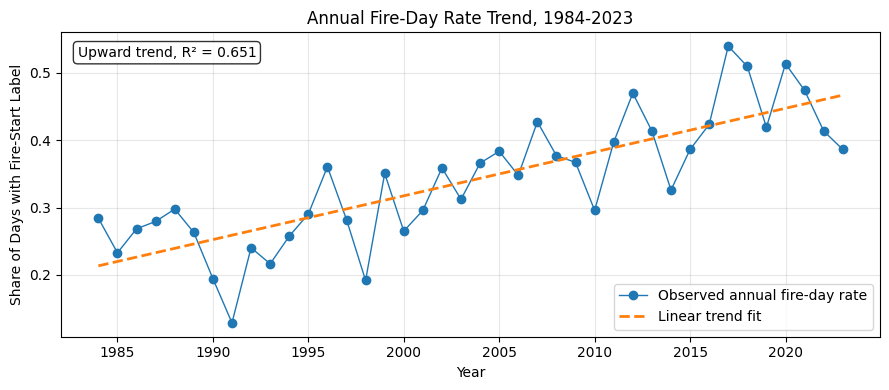

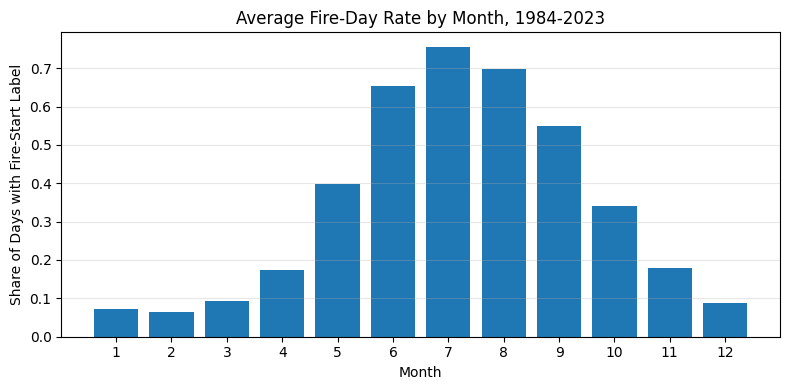

,MONTH,fire_rate,fire_days,total_days
0,1,0.071774,89,1240
1,2,0.065487,74,1130
2,3,0.091935,114,1240
3,4,0.173333,208,1200
4,5,0.397581,493,1240
5,6,0.653333,784,1200
6,7,0.755645,937,1240
7,8,0.698387,866,1240
8,9,0.548333,658,1200
9,10,0.341935,424,1240


In [8]:
# =========================
# Row-level temporal context
# =========================
annual_fire_summary = (
    through_2023_data.groupby("YEAR")
    .agg(
        fire_rate=(TARGET_COLUMN, "mean"),
        fire_days=(TARGET_COLUMN, "sum"),
        total_days=(TARGET_COLUMN, "size"),
        avg_max_temp=("MAX_TEMP", "mean"),
        avg_min_temp=("MIN_TEMP", "mean"),
        avg_wind_speed=("AVG_WIND_SPEED", "mean"),
        total_precipitation=("PRECIPITATION", "sum"),
    )
    .reset_index()
)

monthly_fire_summary = (
    through_2023_data.groupby("MONTH")
    .agg(fire_rate=(TARGET_COLUMN, "mean"), fire_days=(TARGET_COLUMN, "sum"), total_days=(TARGET_COLUMN, "size"))
    .reset_index()
)

annual_fire_summary.to_csv(OUTPUT_DIR / "row_level_annual_fire_summary.csv", index=False)
monthly_fire_summary.to_csv(OUTPUT_DIR / "row_level_monthly_fire_summary.csv", index=False)

slope, intercept = np.polyfit(annual_fire_summary["YEAR"], annual_fire_summary["fire_rate"], 1)
fitted_fire_rate = slope * annual_fire_summary["YEAR"] + intercept
ss_resid = np.sum((annual_fire_summary["fire_rate"] - fitted_fire_rate) ** 2)
ss_total = np.sum((annual_fire_summary["fire_rate"] - annual_fire_summary["fire_rate"].mean()) ** 2)
r_squared = 1 - ss_resid / ss_total

fig, axis = plt.subplots(figsize=(9, 4))
axis.plot(annual_fire_summary["YEAR"], annual_fire_summary["fire_rate"], marker="o", linewidth=1, label="Observed annual fire-day rate")
axis.plot(annual_fire_summary["YEAR"], fitted_fire_rate, linestyle="--", linewidth=2, label="Linear trend fit")
axis.set_title("Annual Fire-Day Rate Trend, 1984-2023")
axis.set_xlabel("Year")
axis.set_ylabel("Share of Days with Fire-Start Label")
axis.annotate(
    f"Upward trend, R² = {r_squared:.3f}" if slope > 0 else f"Downward trend, R² = {r_squared:.3f}",
    xy=(0.02, 0.92),
    xycoords="axes fraction",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8),
)
axis.legend()
axis.grid(alpha=0.3)
plt.tight_layout()
plt.show()

fig, axis = plt.subplots(figsize=(8, 4))
axis.bar(monthly_fire_summary["MONTH"], monthly_fire_summary["fire_rate"])
axis.set_title("Average Fire-Day Rate by Month, 1984-2023")
axis.set_xlabel("Month")
axis.set_ylabel("Share of Days with Fire-Start Label")
axis.set_xticks(range(1, 13))
axis.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

display(monthly_fire_summary)


## 7. Row-Level chronological train/validation/test split

The split is chronological to match the project’s prior evaluation design. The difference is that each row remains one independent sample.


In [9]:
# =========================
# Row-level split
# =========================
def split_by_year_range(
    input_data: pd.DataFrame,
    train_year_range: Tuple[int, int] = TRAIN_YEAR_RANGE,
    validation_year_range: Tuple[int, int] = VALIDATION_YEAR_RANGE,
    test_year_range: Tuple[int, int] = TEST_YEAR_RANGE,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    train_start, train_end = train_year_range
    validation_start, validation_end = validation_year_range
    test_start, test_end = test_year_range

    training_data = input_data[input_data["YEAR"].between(train_start, train_end)].copy()
    validation_data = input_data[input_data["YEAR"].between(validation_start, validation_end)].copy()
    test_data = input_data[input_data["YEAR"].between(test_start, test_end)].copy()

    if training_data.empty or validation_data.empty or test_data.empty:
        raise ValueError("One or more split partitions are empty. Check the year ranges.")

    return training_data, validation_data, test_data


training_data, validation_data, test_data = split_by_year_range(through_2023_data)

X_train = training_data[ROW_LEVEL_FEATURE_COLUMNS].copy()
y_train = training_data[TARGET_COLUMN].copy()
X_val = validation_data[ROW_LEVEL_FEATURE_COLUMNS].copy()
y_val = validation_data[TARGET_COLUMN].copy()
X_test = test_data[ROW_LEVEL_FEATURE_COLUMNS].copy()
y_test = test_data[TARGET_COLUMN].copy()

split_summary = pd.DataFrame([
    {"Split": "Train", "Years": f"{TRAIN_YEAR_RANGE[0]}-{TRAIN_YEAR_RANGE[1]}", "Rows": len(training_data), "Positive rate": y_train.mean()},
    {"Split": "Validation", "Years": f"{VALIDATION_YEAR_RANGE[0]}-{VALIDATION_YEAR_RANGE[1]}", "Rows": len(validation_data), "Positive rate": y_val.mean()},
    {"Split": "Test", "Years": f"{TEST_YEAR_RANGE[0]}-{TEST_YEAR_RANGE[1]}", "Rows": len(test_data), "Positive rate": y_test.mean()},
])
split_summary.to_csv(OUTPUT_DIR / "row_level_split_summary.csv", index=False)
display(split_summary)


,Split,Years,Rows,Positive rate
0,Train,1984-2017,12419,0.320396
1,Validation,2018-2020,1096,0.480839
2,Test,2021-2023,1095,0.424658


## 8. Evaluation helpers

Thresholds are tuned on validation data only. The test set is used for final held-out evaluation after the model and threshold are fixed.


In [10]:
# =========================
# Evaluation helpers
# =========================
def save_result_table(result_table: pd.DataFrame, file_name: str) -> None:
    if not file_name.endswith(".csv"):
        file_name = f"{file_name}.csv"
    output_path = OUTPUT_DIR / file_name
    result_table.to_csv(output_path, index=False)
    print(f"Saved: {output_path}")


def safe_roc_auc(y_true: Sequence[int], predicted_probabilities: Sequence[float]) -> float:
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(roc_auc_score(y_true, predicted_probabilities))


def safe_average_precision(y_true: Sequence[int], predicted_probabilities: Sequence[float]) -> float:
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(average_precision_score(y_true, predicted_probabilities))


def tune_classification_threshold(
    y_true: Sequence[int],
    predicted_probabilities: Sequence[float],
    candidate_thresholds: Optional[np.ndarray] = None,
) -> Tuple[float, pd.DataFrame]:
    if candidate_thresholds is None:
        candidate_thresholds = np.round(np.arange(0.05, 0.951, 0.01), 2)

    threshold_rows = []
    for threshold in candidate_thresholds:
        predicted_labels = (np.asarray(predicted_probabilities) >= threshold).astype(int)
        threshold_rows.append({
            "threshold": float(threshold),
            "precision": precision_score(y_true, predicted_labels, zero_division=0),
            "recall": recall_score(y_true, predicted_labels, zero_division=0),
            "f1": f1_score(y_true, predicted_labels, zero_division=0),
        })

    threshold_table = pd.DataFrame(threshold_rows)
    best_row = threshold_table.sort_values(["f1", "recall", "precision"], ascending=False).iloc[0]
    return float(best_row["threshold"]), threshold_table


def calculate_binary_classification_metrics(
    model_name: str,
    y_validation: Sequence[int],
    validation_probabilities: Sequence[float],
    y_test_values: Sequence[int],
    test_probabilities: Sequence[float],
    selected_threshold: float,
) -> Dict[str, Any]:
    validation_predictions = (np.asarray(validation_probabilities) >= selected_threshold).astype(int)
    test_predictions = (np.asarray(test_probabilities) >= selected_threshold).astype(int)

    return {
        "Model": model_name,
        "Validation ROC-AUC": safe_roc_auc(y_validation, validation_probabilities),
        "Validation PR-AUC": safe_average_precision(y_validation, validation_probabilities),
        "Validation F1": f1_score(y_validation, validation_predictions, zero_division=0),
        "Best threshold": selected_threshold,
        "Test ROC-AUC": safe_roc_auc(y_test_values, test_probabilities),
        "Test PR-AUC": safe_average_precision(y_test_values, test_probabilities),
        "Test Precision": precision_score(y_test_values, test_predictions, zero_division=0),
        "Test Recall": recall_score(y_test_values, test_predictions, zero_division=0),
        "Test F1": f1_score(y_test_values, test_predictions, zero_division=0),
    }


def get_positive_class_probabilities(model_pipeline: Any, input_features: pd.DataFrame) -> np.ndarray:
    if hasattr(model_pipeline, "predict_proba"):
        return model_pipeline.predict_proba(input_features)[:, 1]
    if hasattr(model_pipeline, "decision_function"):
        scores = model_pipeline.decision_function(input_features)
        return 1 / (1 + np.exp(-scores))
    raise TypeError("Model must provide predict_proba or decision_function.")


def fit_and_evaluate_sklearn_model(
    model_name: str,
    model_pipeline: Any,
    X_train_data: pd.DataFrame,
    y_train_data: pd.Series,
    X_validation_data: pd.DataFrame,
    y_validation_data: pd.Series,
    X_test_data: pd.DataFrame,
    y_test_data: pd.Series,
) -> Tuple[Dict[str, Any], Any, float, pd.DataFrame]:
    fitted_model = clone(model_pipeline)
    fitted_model.fit(X_train_data, y_train_data)

    validation_probabilities = get_positive_class_probabilities(fitted_model, X_validation_data)
    test_probabilities = get_positive_class_probabilities(fitted_model, X_test_data)

    selected_threshold, threshold_table = tune_classification_threshold(y_validation_data, validation_probabilities)
    result_row = calculate_binary_classification_metrics(
        model_name=model_name,
        y_validation=y_validation_data,
        validation_probabilities=validation_probabilities,
        y_test_values=y_test_data,
        test_probabilities=test_probabilities,
        selected_threshold=selected_threshold,
    )
    return result_row, fitted_model, selected_threshold, threshold_table


## 9. Row-Level baseline and tree models

These models form the main row_level comparison. They all use the same row-level input matrix and do not construct rolling windows.


In [11]:
# =========================
# Model builders
# =========================
def make_scaled_logistic_regression() -> Pipeline:
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            solver="liblinear",
            class_weight="balanced",
            max_iter=1000,
            random_state=RANDOM_STATE,
        )),
    ])


def make_random_forest_classifier(**overrides: Any) -> Pipeline:
    parameters = {
        "n_estimators": 300 if not FAST_RUN else 50,
        "max_depth": None,
        "min_samples_leaf": 2,
        "class_weight": "balanced",
        "random_state": RANDOM_STATE,
        "n_jobs": SKLEARN_N_JOBS,
    }
    parameters.update(overrides)
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(**parameters)),
    ])


def make_xgboost_classifier(use_gpu: bool = USE_XGBOOST_GPU, **overrides: Any) -> Pipeline:
    negative_count = int((y_train == 0).sum())
    positive_count = int((y_train == 1).sum())
    scale_pos_weight = negative_count / max(positive_count, 1)

    parameters: Dict[str, Any] = {
        "n_estimators": 250 if not FAST_RUN else 50,
        "max_depth": 3,
        "learning_rate": 0.05,
        "subsample": 0.9,
        "colsample_bytree": 0.9,
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "scale_pos_weight": scale_pos_weight,
        "random_state": RANDOM_STATE,
        "n_jobs": XGBOOST_N_JOBS,
        "tree_method": "hist",
    }
    if use_gpu:
        parameters["device"] = "cuda"

    parameters.update(overrides)
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", xgb.XGBClassifier(**parameters)),
    ])


In [12]:
# =========================
# Row-Level baseline models
# =========================
row_level_model_rows: List[Dict[str, Any]] = []
row_level_model_lookup: Dict[str, Any] = {}
row_level_threshold_lookup: Dict[str, float] = {}

if RUN_CORE_MODELS:
    model_specs = [
        ("Dummy baseline", DummyClassifier(strategy="prior", random_state=RANDOM_STATE)),
        ("Logistic Regression", make_scaled_logistic_regression()),
        ("Random Forest", make_random_forest_classifier()),
        ("XGBoost", make_xgboost_classifier()),
    ]

    for model_name, model_pipeline in model_specs:
        result_row, fitted_model, selected_threshold, threshold_table = fit_and_evaluate_sklearn_model(
            model_name=model_name,
            model_pipeline=model_pipeline,
            X_train_data=X_train,
            y_train_data=y_train,
            X_validation_data=X_val,
            y_validation_data=y_val,
            X_test_data=X_test,
            y_test_data=y_test,
        )
        row_level_model_rows.append(result_row)
        row_level_model_lookup[model_name] = fitted_model
        row_level_threshold_lookup[model_name] = selected_threshold
        save_result_table(threshold_table, f"row_level_thresholds_{model_name.lower().replace(' ', '_')}.csv")

row_level_core_model_results = pd.DataFrame(row_level_model_rows).sort_values("Validation PR-AUC", ascending=False).reset_index(drop=True)
save_result_table(row_level_core_model_results, "row_level_core_model_results.csv")
display(row_level_core_model_results)


Saved: /content/wildfire_row_level_one_day_outputs/row_level_thresholds_dummy_baseline.csv
Saved: /content/wildfire_row_level_one_day_outputs/row_level_thresholds_logistic_regression.csv
Saved: /content/wildfire_row_level_one_day_outputs/row_level_thresholds_random_forest.csv
Saved: /content/wildfire_row_level_one_day_outputs/row_level_thresholds_xgboost.csv
Saved: /content/wildfire_row_level_one_day_outputs/row_level_core_model_results.csv


,Model,Validation ROC-AUC,Validation PR-AUC,Validation F1,Best threshold,Test ROC-AUC,Test PR-AUC,Test Precision,Test Recall,Test F1
0,XGBoost,0.852334,0.837668,0.777498,0.30,0.826802,0.757153,0.612855,0.881720,0.723104
1,Random Forest,0.838413,0.812456,0.775439,0.24,0.823246,0.741322,0.645051,0.812903,0.719315
2,Logistic Regression,0.826497,0.792934,0.767123,0.40,0.788848,0.689938,0.641638,0.808602,0.715509
3,Dummy baseline,0.500000,0.480839,0.649415,0.05,0.500000,0.424658,0.424658,1.000000,0.596154


## 10. Validation-based tuning for RF and XGBoost

The small tuning grids below are bounded and validation-based. The test set is not used to choose hyperparameters.


In [13]:
# =========================
# Tuned tree models
# =========================
def run_tuned_model_search(
    model_family_name: str,
    candidate_pipelines: Sequence[Tuple[str, Any, Dict[str, Any]]],
) -> pd.DataFrame:
    search_rows = []
    for candidate_name, candidate_pipeline, candidate_parameters in candidate_pipelines:
        result_row, fitted_model, selected_threshold, threshold_table = fit_and_evaluate_sklearn_model(
            model_name=candidate_name,
            model_pipeline=candidate_pipeline,
            X_train_data=X_train,
            y_train_data=y_train,
            X_validation_data=X_val,
            y_validation_data=y_val,
            X_test_data=X_test,
            y_test_data=y_test,
        )
        result_row.update(candidate_parameters)
        search_rows.append(result_row)
        row_level_model_lookup[candidate_name] = fitted_model
        row_level_threshold_lookup[candidate_name] = selected_threshold
        save_result_table(threshold_table, f"row_level_thresholds_{candidate_name.lower().replace(' ', '_')}.csv")

    search_results = pd.DataFrame(search_rows).sort_values("Validation PR-AUC", ascending=False).reset_index(drop=True)
    save_result_table(search_results, f"row_level_{model_family_name.lower().replace(' ', '_')}_search.csv")
    return search_results


if RUN_TUNED_TREE_MODELS:
    rf_candidates = [
        ("Tuned Random Forest candidate 1", make_random_forest_classifier(n_estimators=300, max_depth=8, min_samples_leaf=2, max_features="sqrt"), {"n_estimators": 300, "max_depth": 8, "min_samples_leaf": 2, "max_features": "sqrt"}),
        ("Tuned Random Forest candidate 2", make_random_forest_classifier(n_estimators=300, max_depth=None, min_samples_leaf=2, max_features="sqrt"), {"n_estimators": 300, "max_depth": None, "min_samples_leaf": 2, "max_features": "sqrt"}),
        ("Tuned Random Forest candidate 3", make_random_forest_classifier(n_estimators=500, max_depth=10, min_samples_leaf=3, max_features="sqrt"), {"n_estimators": 500, "max_depth": 10, "min_samples_leaf": 3, "max_features": "sqrt"}),
        ("Tuned Random Forest candidate 4", make_random_forest_classifier(n_estimators=500, max_depth=14, min_samples_leaf=2, max_features="log2"), {"n_estimators": 500, "max_depth": 14, "min_samples_leaf": 2, "max_features": "log2"}),
        ("Tuned Random Forest candidate 5", make_random_forest_classifier(n_estimators=700, max_depth=10, min_samples_leaf=4, max_features="sqrt"), {"n_estimators": 700, "max_depth": 10, "min_samples_leaf": 4, "max_features": "sqrt"}),
    ]
    if FAST_RUN:
        rf_candidates = rf_candidates[:2]

    tuned_random_forest_search = run_tuned_model_search("Tuned Random Forest", rf_candidates)
    display(tuned_random_forest_search)

    best_rf_candidate_name = str(tuned_random_forest_search.iloc[0]["Model"])
    row_level_model_lookup["Tuned Random Forest"] = row_level_model_lookup[best_rf_candidate_name]
    row_level_threshold_lookup["Tuned Random Forest"] = row_level_threshold_lookup[best_rf_candidate_name]
    best_rf_result = tuned_random_forest_search.iloc[0].copy()
    best_rf_result["Model"] = "Tuned Random Forest"
    row_level_model_rows.append(best_rf_result.to_dict())

    xgb_candidates = [
        ("Tuned XGBoost candidate 1", make_xgboost_classifier(n_estimators=250, max_depth=3, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9), {"n_estimators": 250, "max_depth": 3, "learning_rate": 0.05}),
        ("Tuned XGBoost candidate 2", make_xgboost_classifier(n_estimators=350, max_depth=3, learning_rate=0.03, subsample=0.9, colsample_bytree=0.9), {"n_estimators": 350, "max_depth": 3, "learning_rate": 0.03}),
        ("Tuned XGBoost candidate 3", make_xgboost_classifier(n_estimators=300, max_depth=4, learning_rate=0.04, subsample=0.85, colsample_bytree=0.85), {"n_estimators": 300, "max_depth": 4, "learning_rate": 0.04}),
        ("Tuned XGBoost candidate 4", make_xgboost_classifier(n_estimators=450, max_depth=2, learning_rate=0.03, subsample=0.95, colsample_bytree=0.9), {"n_estimators": 450, "max_depth": 2, "learning_rate": 0.03}),
    ]
    if FAST_RUN:
        xgb_candidates = xgb_candidates[:2]

    tuned_xgboost_search = run_tuned_model_search("Tuned XGBoost", xgb_candidates)
    display(tuned_xgboost_search)

    best_xgb_candidate_name = str(tuned_xgboost_search.iloc[0]["Model"])
    row_level_model_lookup["Tuned XGBoost"] = row_level_model_lookup[best_xgb_candidate_name]
    row_level_threshold_lookup["Tuned XGBoost"] = row_level_threshold_lookup[best_xgb_candidate_name]
    best_xgb_result = tuned_xgboost_search.iloc[0].copy()
    best_xgb_result["Model"] = "Tuned XGBoost"
    row_level_model_rows.append(best_xgb_result.to_dict())

row_level_model_results = pd.DataFrame(row_level_model_rows).drop_duplicates(subset=["Model"], keep="last")
row_level_model_results = row_level_model_results.sort_values("Validation PR-AUC", ascending=False).reset_index(drop=True)
save_result_table(row_level_model_results, "row_level_model_results_with_tuned_trees.csv")
display(row_level_model_results)


Saved: /content/wildfire_row_level_one_day_outputs/row_level_thresholds_tuned_random_forest_candidate_1.csv
Saved: /content/wildfire_row_level_one_day_outputs/row_level_thresholds_tuned_random_forest_candidate_2.csv
Saved: /content/wildfire_row_level_one_day_outputs/row_level_thresholds_tuned_random_forest_candidate_3.csv
Saved: /content/wildfire_row_level_one_day_outputs/row_level_thresholds_tuned_random_forest_candidate_4.csv
Saved: /content/wildfire_row_level_one_day_outputs/row_level_thresholds_tuned_random_forest_candidate_5.csv
Saved: /content/wildfire_row_level_one_day_outputs/row_level_tuned_random_forest_search.csv


,Model,Validation ROC-AUC,Validation PR-AUC,Validation F1,Best threshold,Test ROC-AUC,Test PR-AUC,Test Precision,Test Recall,Test F1,n_estimators,max_depth,min_samples_leaf,max_features
0,Tuned Random Forest candidate 3,0.849948,0.833112,0.779983,0.29,0.831145,0.753104,0.634304,0.843011,0.723915,500,10.0,3,sqrt
1,Tuned Random Forest candidate 5,0.850012,0.832897,0.777015,0.29,0.831176,0.754533,0.634185,0.853763,0.727773,700,10.0,4,sqrt
2,Tuned Random Forest candidate 1,0.850165,0.830551,0.781609,0.33,0.830937,0.753977,0.648649,0.825806,0.726585,300,8.0,2,sqrt
3,Tuned Random Forest candidate 4,0.844916,0.824679,0.778639,0.25,0.828080,0.749656,0.637705,0.836559,0.723721,500,14.0,2,log2
4,Tuned Random Forest candidate 2,0.838413,0.812456,0.775439,0.24,0.823246,0.741322,0.645051,0.812903,0.719315,300,NaN,2,sqrt


Saved: /content/wildfire_row_level_one_day_outputs/row_level_thresholds_tuned_xgboost_candidate_1.csv
Saved: /content/wildfire_row_level_one_day_outputs/row_level_thresholds_tuned_xgboost_candidate_2.csv
Saved: /content/wildfire_row_level_one_day_outputs/row_level_thresholds_tuned_xgboost_candidate_3.csv
Saved: /content/wildfire_row_level_one_day_outputs/row_level_thresholds_tuned_xgboost_candidate_4.csv
Saved: /content/wildfire_row_level_one_day_outputs/row_level_tuned_xgboost_search.csv


,Model,Validation ROC-AUC,Validation PR-AUC,Validation F1,Best threshold,Test ROC-AUC,Test PR-AUC,Test Precision,Test Recall,Test F1,n_estimators,max_depth,learning_rate
0,Tuned XGBoost candidate 1,0.852334,0.837668,0.777498,0.30,0.826802,0.757153,0.612855,0.881720,0.723104,250,3,0.05
1,Tuned XGBoost candidate 2,0.851927,0.837230,0.780239,0.32,0.826602,0.755580,0.630503,0.862366,0.728429,350,3,0.03
2,Tuned XGBoost candidate 4,0.852718,0.836526,0.781588,0.40,0.826249,0.754525,0.664865,0.793548,0.723529,450,2,0.03
3,Tuned XGBoost candidate 3,0.851029,0.833898,0.779863,0.31,0.826291,0.754707,0.621914,0.866667,0.724169,300,4,0.04


Saved: /content/wildfire_row_level_one_day_outputs/row_level_model_results_with_tuned_trees.csv


,Model,Validation ROC-AUC,Validation PR-AUC,Validation F1,Best threshold,Test ROC-AUC,Test PR-AUC,Test Precision,Test Recall,Test F1,n_estimators,max_depth,min_samples_leaf,max_features,learning_rate
0,Tuned XGBoost,0.852334,0.837668,0.777498,0.30,0.826802,0.757153,0.612855,0.881720,0.723104,250.0,3.0,NaN,NaN,0.05
1,XGBoost,0.852334,0.837668,0.777498,0.30,0.826802,0.757153,0.612855,0.881720,0.723104,NaN,NaN,NaN,NaN,NaN
2,Tuned Random Forest,0.849948,0.833112,0.779983,0.29,0.831145,0.753104,0.634304,0.843011,0.723915,500.0,10.0,3.0,sqrt,NaN
3,Random Forest,0.838413,0.812456,0.775439,0.24,0.823246,0.741322,0.645051,0.812903,0.719315,NaN,NaN,NaN,NaN,NaN
4,Logistic Regression,0.826497,0.792934,0.767123,0.40,0.788848,0.689938,0.641638,0.808602,0.715509,NaN,NaN,NaN,NaN,NaN
5,Dummy baseline,0.500000,0.480839,0.649415,0.05,0.500000,0.424658,0.424658,1.000000,0.596154,NaN,NaN,NaN,NaN,NaN


## 11. Row-Level model comparison plots

These plots summarize the row-level model performance. The final selected neural baseline is added later after it is trained.


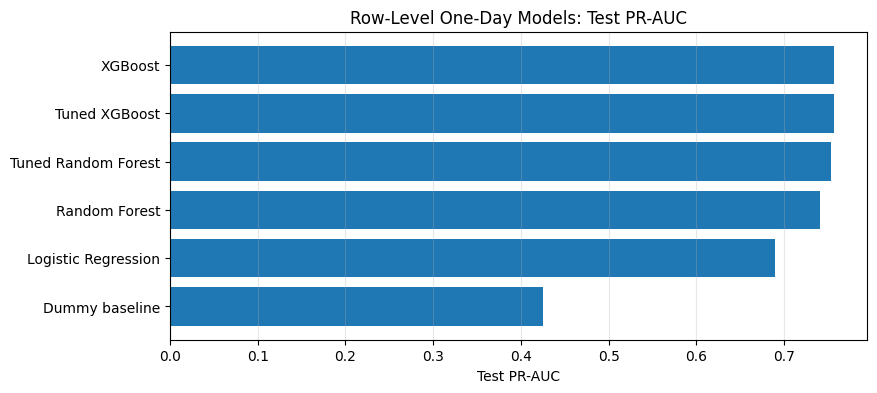

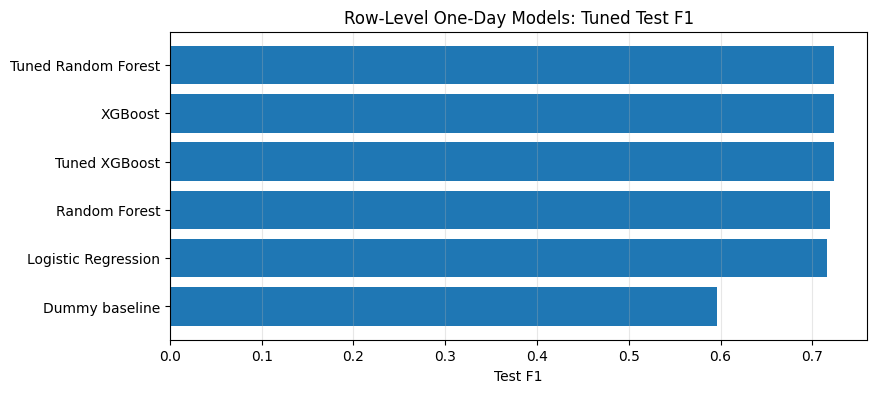

In [14]:
# =========================
# Row-Level model comparison plots
# =========================
def plot_metric_comparison(result_table: pd.DataFrame, metric_column: str, title: str) -> None:
    plot_table = result_table.sort_values(metric_column, ascending=True)
    fig, axis = plt.subplots(figsize=(9, 4))
    axis.barh(plot_table["Model"], plot_table[metric_column])
    axis.set_title(title)
    axis.set_xlabel(metric_column)
    axis.grid(axis="x", alpha=0.3)
    plt.show()


if not row_level_model_results.empty:
    plot_metric_comparison(row_level_model_results, "Test PR-AUC", "Row-Level One-Day Models: Test PR-AUC")
    plot_metric_comparison(row_level_model_results, "Test F1", "Row-Level One-Day Models: Tuned Test F1")


## 12. Row-Level feature relevance

Feature relevance is computed from the row-level models. This is the primary interpretation source for the final report.


In [15]:
# =========================
# Feature relevance helpers
# =========================
def make_feature_importance_table(
    model_name: str,
    model_pipeline: Any,
    feature_columns: Sequence[str],
) -> pd.DataFrame:
    fitted_estimator = model_pipeline.named_steps.get("model") if isinstance(model_pipeline, Pipeline) else model_pipeline

    if hasattr(fitted_estimator, "feature_importances_"):
        importance_values = np.asarray(fitted_estimator.feature_importances_, dtype=float)
        importance_type = "model_importance"
    elif hasattr(fitted_estimator, "coef_"):
        importance_values = np.abs(np.asarray(fitted_estimator.coef_).reshape(-1))
        importance_type = "absolute_coefficient"
    else:
        raise TypeError(f"Model {model_name} does not expose feature importances or coefficients.")

    if len(importance_values) != len(feature_columns):
        raise ValueError(f"Feature importance length mismatch for {model_name}.")

    total_importance = importance_values.sum()
    normalized_importance = importance_values / total_importance if total_importance > 0 else importance_values

    return pd.DataFrame({
        "Model": model_name,
        "Feature": list(feature_columns),
        "Importance": importance_values,
        "Normalized importance": normalized_importance,
        "Importance type": importance_type,
    }).sort_values("Normalized importance", ascending=False).reset_index(drop=True)


def plot_top_feature_importance(importance_table: pd.DataFrame, model_name: str, top_n: int = 10) -> None:
    plot_table = importance_table.head(top_n).sort_values("Normalized importance", ascending=True)
    fig, axis = plt.subplots(figsize=(8, 4.5))
    axis.barh(plot_table["Feature"], plot_table["Normalized importance"])
    axis.set_title(f"Top Row-Level Feature Importances: {model_name}")
    axis.set_xlabel("Normalized importance")
    axis.grid(axis="x", alpha=0.3)
    plt.show()


Saved: /content/wildfire_row_level_one_day_outputs/row_level_feature_importance_logistic_regression.csv


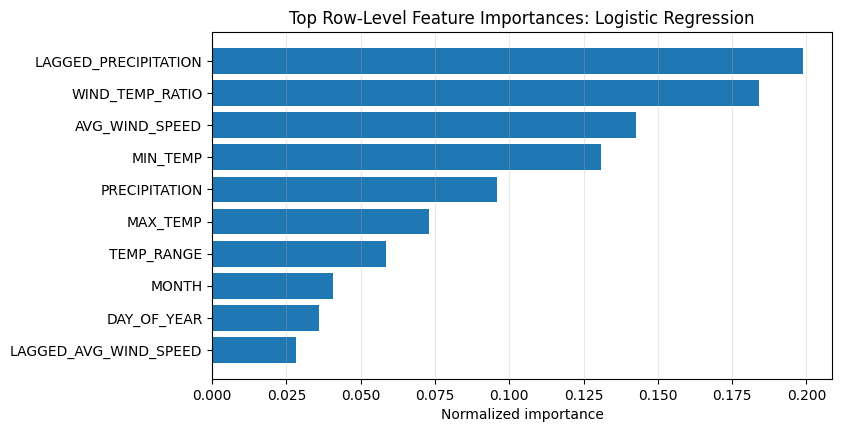

Saved: /content/wildfire_row_level_one_day_outputs/row_level_feature_importance_random_forest.csv


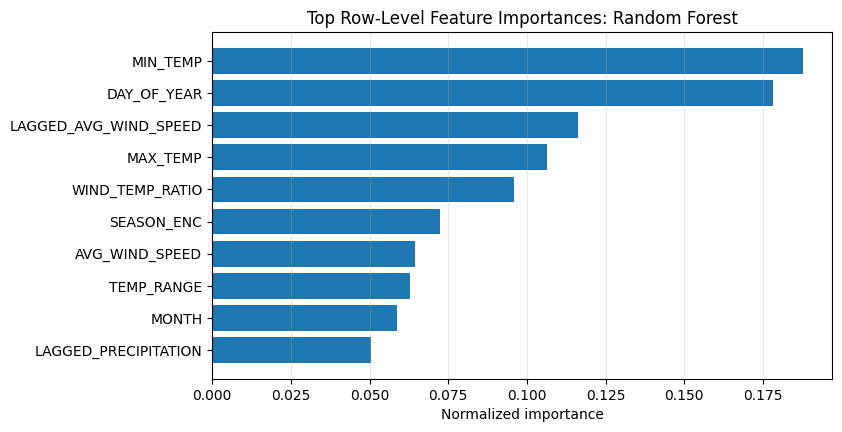

Saved: /content/wildfire_row_level_one_day_outputs/row_level_feature_importance_xgboost.csv


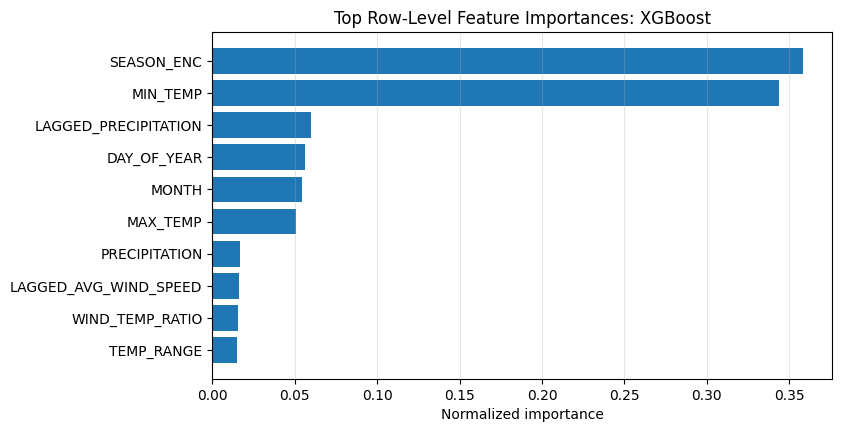

Saved: /content/wildfire_row_level_one_day_outputs/row_level_feature_importance_tuned_random_forest.csv


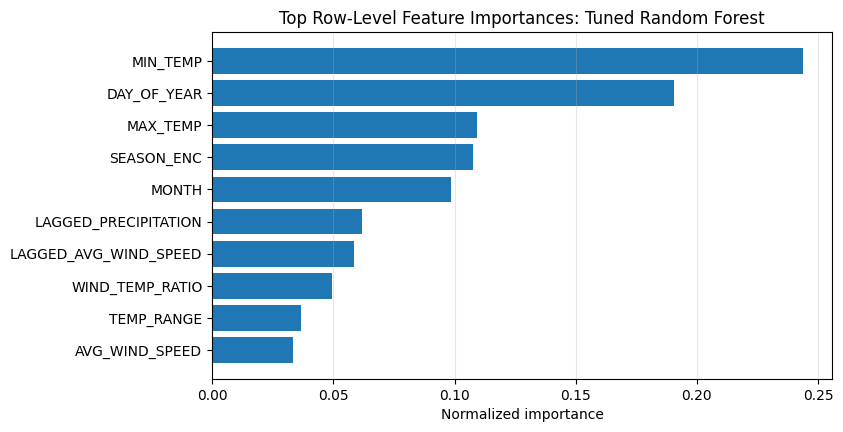

Saved: /content/wildfire_row_level_one_day_outputs/row_level_feature_importance_tuned_xgboost.csv


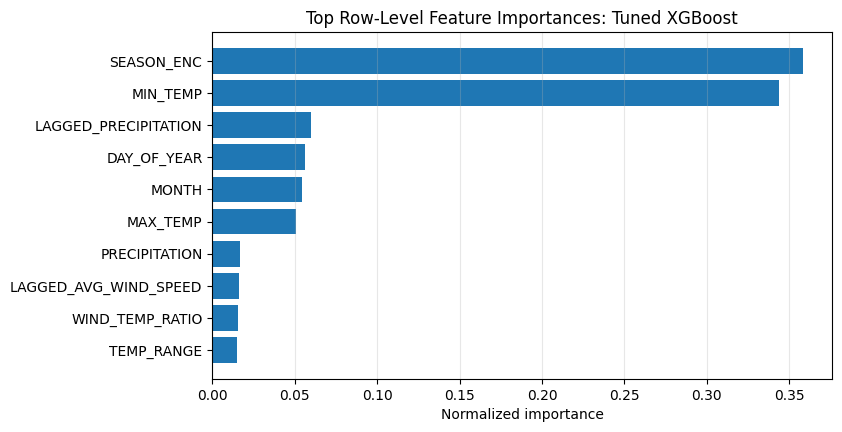

Saved: /content/wildfire_row_level_one_day_outputs/row_level_feature_importance_summary.csv


,Model,Feature,Importance,Normalized importance,Importance type
0,Logistic Regression,LAGGED_PRECIPITATION,0.979415,0.198762,absolute_coefficient
1,Logistic Regression,WIND_TEMP_RATIO,0.907030,0.184073,absolute_coefficient
2,Logistic Regression,AVG_WIND_SPEED,0.702996,0.142666,absolute_coefficient
3,Logistic Regression,MIN_TEMP,0.644195,0.130733,absolute_coefficient
4,Logistic Regression,PRECIPITATION,0.472674,0.095924,absolute_coefficient
5,Logistic Regression,MAX_TEMP,0.359435,0.072944,absolute_coefficient
6,Logistic Regression,TEMP_RANGE,0.288539,0.058556,absolute_coefficient
7,Logistic Regression,MONTH,0.200048,0.040598,absolute_coefficient
8,Logistic Regression,DAY_OF_YEAR,0.177509,0.036024,absolute_coefficient
9,Logistic Regression,LAGGED_AVG_WIND_SPEED,0.139140,0.028237,absolute_coefficient


In [16]:
# =========================
# Row-Level feature relevance tables
# =========================
row_level_feature_importance_tables: List[pd.DataFrame] = []

if RUN_FEATURE_RELEVANCE and RUN_CORE_MODELS:
    feature_importance_model_names = [
        model_name for model_name in [
            "Logistic Regression",
            "Random Forest",
            "XGBoost",
            "Tuned Random Forest",
            "Tuned XGBoost",
        ]
        if model_name in row_level_model_lookup
    ]

    for model_name in feature_importance_model_names:
        importance_table = make_feature_importance_table(
            model_name=model_name,
            model_pipeline=row_level_model_lookup[model_name],
            feature_columns=ROW_LEVEL_FEATURE_COLUMNS,
        )
        row_level_feature_importance_tables.append(importance_table)
        save_result_table(importance_table, f"row_level_feature_importance_{model_name.lower().replace(' ', '_')}.csv")
        plot_top_feature_importance(importance_table, model_name)

    row_level_feature_importance_summary = pd.concat(row_level_feature_importance_tables, ignore_index=True)
    save_result_table(row_level_feature_importance_summary, "row_level_feature_importance_summary.csv")
else:
    row_level_feature_importance_summary = pd.DataFrame()

if not row_level_feature_importance_summary.empty:
    display(row_level_feature_importance_summary.head(25))


## 13. Feature relevance comparison with the temporal-windowed branch

This section does not treat the temporal-windowed windowed model as the row_level predictive task. It only compares feature-level intuition by aggregating old windowed importances back to base feature names.


In [17]:
# =========================
# Temporal-windowed feature relevance comparison helpers
# =========================
def make_windowed_feature_names(base_features: Sequence[str], window_size: int) -> List[str]:
    feature_names: List[str] = []
    for day_offset in range(window_size):
        for feature_name in base_features:
            feature_names.append(f"{feature_name}_day_{day_offset + 1}")
    return feature_names


def build_temporal_windowed_reference_dataset(
    input_data: pd.DataFrame,
    base_features: Sequence[str],
    window_size: int = TEMPORAL_REFERENCE_WINDOW_SIZE,
) -> Tuple[pd.DataFrame, pd.Series, pd.Series]:
    required_columns = list(base_features) + [TARGET_COLUMN, "YEAR"]
    working_data = input_data[required_columns].replace([np.inf, -np.inf], np.nan).dropna().copy().reset_index(drop=True)
    feature_matrix = working_data[list(base_features)].to_numpy(dtype=float)
    raw_windows = np.lib.stride_tricks.sliding_window_view(feature_matrix, window_shape=window_size, axis=0)
    window_array = np.transpose(raw_windows, (0, 2, 1))[:-1]
    flattened_windows = window_array.reshape(window_array.shape[0], -1)

    target_values = working_data[TARGET_COLUMN].iloc[window_size:].reset_index(drop=True)
    target_years = working_data["YEAR"].iloc[window_size:].reset_index(drop=True)
    windowed_feature_names = make_windowed_feature_names(base_features, window_size)

    windowed_features = pd.DataFrame(flattened_windows, columns=windowed_feature_names)
    return windowed_features, target_values, target_years


def aggregate_windowed_feature_importance(
    windowed_importance: pd.DataFrame,
    output_column_name: str,
) -> pd.DataFrame:
    aggregated_rows = []
    for _, importance_row in windowed_importance.iterrows():
        feature_name = str(importance_row["Feature"])
        base_feature_name = feature_name.rsplit("_day_", 1)[0] if "_day_" in feature_name else feature_name
        aggregated_rows.append({
            "Feature": base_feature_name,
            "Importance": float(importance_row["Importance"]),
        })

    aggregated_table = pd.DataFrame(aggregated_rows).groupby("Feature", as_index=False)["Importance"].sum()
    total_importance = aggregated_table["Importance"].sum()
    aggregated_table[output_column_name] = aggregated_table["Importance"] / total_importance if total_importance > 0 else aggregated_table["Importance"]
    return aggregated_table.sort_values(output_column_name, ascending=False).reset_index(drop=True)


def train_temporal_windowed_reference_importance(
    input_data: pd.DataFrame,
    feature_columns: Sequence[str],
    reference_label: str,
) -> pd.DataFrame:
    windowed_features, windowed_target, windowed_years = build_temporal_windowed_reference_dataset(
        input_data,
        base_features=feature_columns,
        window_size=TEMPORAL_REFERENCE_WINDOW_SIZE,
    )

    train_mask = windowed_years.between(*TRAIN_YEAR_RANGE)
    windowed_X_train = windowed_features.loc[train_mask].reset_index(drop=True)
    windowed_y_train = windowed_target.loc[train_mask].reset_index(drop=True)

    reference_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=300 if not FAST_RUN else 50,
            max_depth=10,
            min_samples_leaf=3,
            max_features="sqrt",
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=1,
        )),
    ])
    reference_model.fit(windowed_X_train, windowed_y_train)
    return make_feature_importance_table(
        model_name=reference_label,
        model_pipeline=reference_model,
        feature_columns=windowed_X_train.columns,
    )


def compare_row_level_and_temporal_importance(
    row_level_importance: pd.DataFrame,
    temporal_importance: pd.DataFrame,
    row_level_model_name: str,
    temporal_importance_column: str,
) -> pd.DataFrame:
    row_level_model_importance = row_level_importance[row_level_importance["Model"] == row_level_model_name].copy()
    row_level_model_importance = row_level_model_importance[["Feature", "Normalized importance"]].rename(
        columns={"Normalized importance": "Row-level normalized importance"}
    )
    comparison_table = row_level_model_importance.merge(
        temporal_importance[["Feature", temporal_importance_column]],
        on="Feature",
        how="outer",
    ).fillna(0)
    comparison_table["Importance difference"] = comparison_table["Row-level normalized importance"] - comparison_table[temporal_importance_column]
    return comparison_table.sort_values("Row-level normalized importance", ascending=False).reset_index(drop=True)


Saved: /content/wildfire_row_level_one_day_outputs/temporal_windowed_reference_importance_raw.csv
Saved: /content/wildfire_row_level_one_day_outputs/temporal_windowed_reference_importance_aggregated.csv
Saved: /content/wildfire_row_level_one_day_outputs/temporal_windowed_engineered_reference_importance_raw.csv
Saved: /content/wildfire_row_level_one_day_outputs/temporal_windowed_engineered_reference_importance_aggregated.csv
Saved: /content/wildfire_row_level_one_day_outputs/row_level_vs_temporal_windowed_feature_relevance.csv


,Feature,Row-level normalized importance,Temporal-windowed normalized importance,Importance difference
0,MIN_TEMP,0.243648,0.331847,-0.088199
1,DAY_OF_YEAR,0.190646,0.182945,0.007701
2,MAX_TEMP,0.109373,0.060219,0.049154
3,SEASON_ENC,0.107583,0.097433,0.010150
4,MONTH,0.098328,0.059461,0.038867
5,LAGGED_PRECIPITATION,0.062004,0.037793,0.024212
6,LAGGED_AVG_WIND_SPEED,0.058690,0.064564,-0.005875
7,WIND_TEMP_RATIO,0.049396,0.068045,-0.018649
8,TEMP_RANGE,0.036803,0.043403,-0.006600
9,AVG_WIND_SPEED,0.033524,0.047853,-0.014329


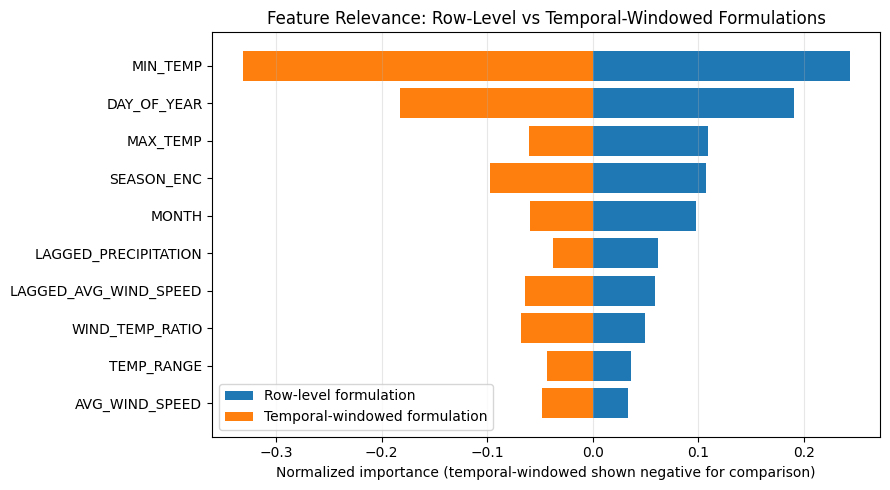

In [18]:
# =========================
# Compare row-level importance against temporal-windowed references
# =========================
if RUN_TEMPORAL_WINDOWED_REFERENCE_COMPARISON and RUN_FEATURE_RELEVANCE and not row_level_feature_importance_summary.empty:
    temporal_windowed_base_importance = train_temporal_windowed_reference_importance(
        input_data=through_2023_data,
        feature_columns=ROW_LEVEL_FEATURE_COLUMNS,
        reference_label="Temporal-windowed RF reference — row-level features",
    )
    save_result_table(temporal_windowed_base_importance, "temporal_windowed_reference_importance_raw.csv")

    aggregated_temporal_base_importance = aggregate_windowed_feature_importance(
        temporal_windowed_base_importance,
        output_column_name="Temporal-windowed normalized importance",
    )
    save_result_table(aggregated_temporal_base_importance, "temporal_windowed_reference_importance_aggregated.csv")

    temporal_engineered_reference_importance = pd.DataFrame()
    aggregated_temporal_engineered_importance = pd.DataFrame()
    if RUN_TEMPORAL_ENGINEERED_REFERENCE:
        temporal_engineered_reference_importance = train_temporal_windowed_reference_importance(
            input_data=temporal_engineered_data,
            feature_columns=TEMPORAL_ENGINEERED_FEATURE_COLUMNS,
            reference_label="Temporal-windowed RF reference — systematic engineered features",
        )
        save_result_table(temporal_engineered_reference_importance, "temporal_windowed_engineered_reference_importance_raw.csv")
        aggregated_temporal_engineered_importance = aggregate_windowed_feature_importance(
            temporal_engineered_reference_importance,
            output_column_name="Temporal-windowed engineered normalized importance",
        )
        save_result_table(aggregated_temporal_engineered_importance, "temporal_windowed_engineered_reference_importance_aggregated.csv")

    preferred_row_level_importance_model = "Tuned Random Forest" if "Tuned Random Forest" in row_level_model_lookup else "Random Forest"
    feature_relevance_comparison = compare_row_level_and_temporal_importance(
        row_level_importance=row_level_feature_importance_summary,
        temporal_importance=aggregated_temporal_base_importance,
        row_level_model_name=preferred_row_level_importance_model,
        temporal_importance_column="Temporal-windowed normalized importance",
    )
    save_result_table(feature_relevance_comparison, "row_level_vs_temporal_windowed_feature_relevance.csv")
    display(feature_relevance_comparison)

    plot_table = feature_relevance_comparison.head(10).sort_values("Row-level normalized importance", ascending=True)
    fig, axis = plt.subplots(figsize=(9, 5))
    axis.barh(plot_table["Feature"], plot_table["Row-level normalized importance"], label="Row-level formulation")
    axis.barh(plot_table["Feature"], -plot_table["Temporal-windowed normalized importance"], label="Temporal-windowed formulation")
    axis.set_title("Feature Relevance: Row-Level vs Temporal-Windowed Formulations")
    axis.set_xlabel("Normalized importance (temporal-windowed shown negative for comparison)")
    axis.legend()
    axis.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    feature_relevance_comparison = pd.DataFrame()
    temporal_windowed_base_importance = pd.DataFrame()
    aggregated_temporal_base_importance = pd.DataFrame()
    temporal_engineered_reference_importance = pd.DataFrame()
    aggregated_temporal_engineered_importance = pd.DataFrame()


## 14. Row-Level error analysis

The error analysis is based on the best row_level tree model by validation PR-AUC. This keeps the interpretation tied to the row-level task.


In [19]:
# =========================
# Row-Level error analysis
# =========================
def build_prediction_analysis_table(
    source_data: pd.DataFrame,
    y_true: pd.Series,
    predicted_probabilities: np.ndarray,
    threshold: float,
) -> pd.DataFrame:
    analysis_table = source_data[[DATE_COLUMN, "YEAR", "MONTH", "SEASON", TARGET_COLUMN]].copy()
    analysis_table["actual_label"] = np.asarray(y_true).astype(int)
    analysis_table["predicted_probability"] = predicted_probabilities
    analysis_table["predicted_label"] = (predicted_probabilities >= threshold).astype(int)
    analysis_table["error_type"] = np.select(
        [
            (analysis_table["actual_label"] == 1) & (analysis_table["predicted_label"] == 1),
            (analysis_table["actual_label"] == 0) & (analysis_table["predicted_label"] == 0),
            (analysis_table["actual_label"] == 0) & (analysis_table["predicted_label"] == 1),
            (analysis_table["actual_label"] == 1) & (analysis_table["predicted_label"] == 0),
        ],
        ["true_positive", "true_negative", "false_positive", "false_negative"],
        default="unknown",
    )
    return analysis_table


if RUN_ERROR_ANALYSIS and not row_level_model_results.empty:
    candidate_tree_models = [model_name for model_name in ["Tuned XGBoost", "Tuned Random Forest", "XGBoost", "Random Forest"] if model_name in row_level_model_lookup]
    best_tree_model_name = sorted(
        candidate_tree_models,
        key=lambda name: float(row_level_model_results.loc[row_level_model_results["Model"] == name, "Validation PR-AUC"].iloc[0]),
        reverse=True,
    )[0]

    best_tree_model = row_level_model_lookup[best_tree_model_name]
    best_tree_threshold = row_level_threshold_lookup[best_tree_model_name]
    best_tree_test_probabilities = get_positive_class_probabilities(best_tree_model, X_test)

    row_level_test_predictions = build_prediction_analysis_table(
        source_data=test_data,
        y_true=y_test,
        predicted_probabilities=best_tree_test_probabilities,
        threshold=best_tree_threshold,
    )
    save_result_table(row_level_test_predictions, "row_level_test_predictions.csv")

    row_level_error_type_summary = row_level_test_predictions["error_type"].value_counts().rename_axis("error_type").reset_index(name="count")
    save_result_table(row_level_error_type_summary, "row_level_error_type_summary.csv")
    display(row_level_error_type_summary)

    seasonal_error_summary = (
        row_level_test_predictions.groupby("SEASON")
        .agg(
            total_days=("actual_label", "size"),
            fire_days=("actual_label", "sum"),
            predicted_fire_days=("predicted_label", "sum"),
            false_negatives=("error_type", lambda values: int((values == "false_negative").sum())),
            false_positives=("error_type", lambda values: int((values == "false_positive").sum())),
        )
        .reset_index()
    )
    seasonal_error_summary["false_negative_rate_among_fire_days"] = seasonal_error_summary["false_negatives"] / seasonal_error_summary["fire_days"].replace(0, np.nan)
    save_result_table(seasonal_error_summary, "row_level_errors_by_season.csv")
    display(seasonal_error_summary)

    yearly_error_summary = (
        row_level_test_predictions.groupby("YEAR")
        .agg(
            total_days=("actual_label", "size"),
            fire_days=("actual_label", "sum"),
            false_negatives=("error_type", lambda values: int((values == "false_negative").sum())),
            false_positives=("error_type", lambda values: int((values == "false_positive").sum())),
        )
        .reset_index()
    )
    save_result_table(yearly_error_summary, "row_level_errors_by_year.csv")
    display(yearly_error_summary)

    high_confidence_false_negatives = row_level_test_predictions[row_level_test_predictions["error_type"] == "false_negative"].sort_values("predicted_probability", ascending=False).head(15)
    high_confidence_false_positives = row_level_test_predictions[row_level_test_predictions["error_type"] == "false_positive"].sort_values("predicted_probability", ascending=False).head(15)
    save_result_table(high_confidence_false_negatives, "row_level_high_confidence_false_negatives.csv")
    save_result_table(high_confidence_false_positives, "row_level_high_confidence_false_positives.csv")

    print(f"Error analysis model: {best_tree_model_name}")
    print(f"Validation-selected threshold: {best_tree_threshold:.2f}")
else:
    row_level_test_predictions = pd.DataFrame()


Saved: /content/wildfire_row_level_one_day_outputs/row_level_test_predictions.csv
Saved: /content/wildfire_row_level_one_day_outputs/row_level_error_type_summary.csv


,error_type,count
0,true_positive,410
1,true_negative,371
2,false_positive,259
3,false_negative,55


Saved: /content/wildfire_row_level_one_day_outputs/row_level_errors_by_season.csv


,SEASON,total_days,fire_days,predicted_fire_days,false_negatives,false_positives,false_negative_rate_among_fire_days
0,Fall,273,99,235,5,141,0.050505
1,Spring,276,110,130,30,50,0.272727
2,Summer,276,227,275,1,49,0.004405
3,Winter,270,29,29,19,19,0.655172


Saved: /content/wildfire_row_level_one_day_outputs/row_level_errors_by_year.csv


,YEAR,total_days,fire_days,false_negatives,false_positives
0,2021,365,173,23,89
1,2022,365,151,21,83
2,2023,365,141,11,87


Saved: /content/wildfire_row_level_one_day_outputs/row_level_high_confidence_false_negatives.csv
Saved: /content/wildfire_row_level_one_day_outputs/row_level_high_confidence_false_positives.csv
Error analysis model: Tuned XGBoost
Validation-selected threshold: 0.30


## 14b. Probability calibration

This section explains the threshold behaviour observed in Section 3.1 of the report.
A reliability diagram shows whether predicted probabilities match observed fire rates.
The Brier score provides a single-number calibration summary.

All diagnostics use the **test set only** after thresholds are already locked.
No new tuning or re-fitting is introduced here.

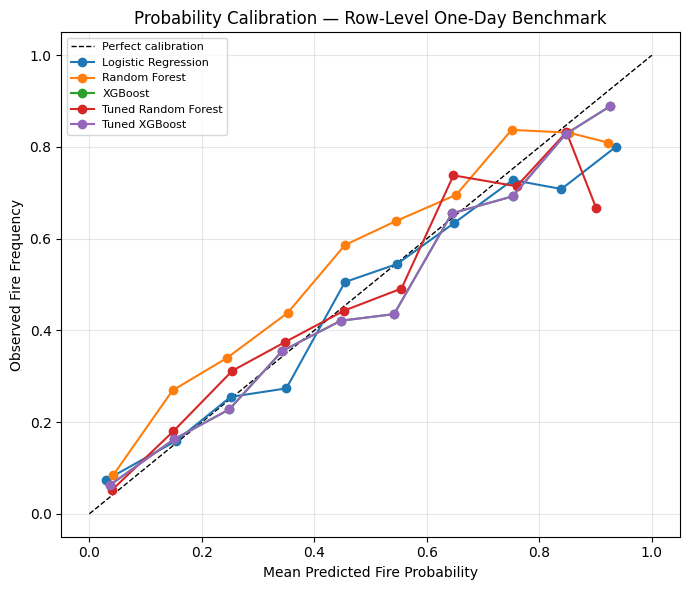

Saved: /content/wildfire_row_level_one_day_outputs/row_level_calibration_summary.csv


,Model,Brier score,Selected threshold,Mean predicted probability,Actual positive rate
3,Tuned Random Forest,0.1653,0.29,0.4138,0.4247
2,XGBoost,0.1674,0.30,0.4365,0.4247
4,Tuned XGBoost,0.1674,0.30,0.4365,0.4247
1,Random Forest,0.1759,0.24,0.3550,0.4247
0,Logistic Regression,0.1853,0.40,0.4418,0.4247


In [20]:
# =========================
# Probability calibration — reliability diagram and Brier scores
# =========================
RUN_CALIBRATION = True

if RUN_CALIBRATION and RUN_CORE_MODELS:
    from sklearn.calibration import calibration_curve
    from sklearn.metrics import brier_score_loss

    CALIBRATION_MODEL_NAMES: List[str] = [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Tuned Random Forest",
        "Tuned XGBoost",
    ]

    calibration_rows: List[Dict[str, Any]] = []
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")

    for model_name in CALIBRATION_MODEL_NAMES:
        if model_name not in row_level_model_lookup:
            continue

        test_probabilities = get_positive_class_probabilities(row_level_model_lookup[model_name], X_test)
        brier = brier_score_loss(y_test, test_probabilities)
        selected_threshold = row_level_threshold_lookup.get(model_name, 0.50)

        prob_true, prob_pred = calibration_curve(y_test, test_probabilities, n_bins=10, strategy="uniform")
        ax.plot(prob_pred, prob_true, marker="o", linewidth=1.5, label=model_name)

        calibration_rows.append({
            "Model": model_name,
            "Brier score": round(brier, 4),
            "Selected threshold": selected_threshold,
            "Mean predicted probability": round(float(np.mean(test_probabilities)), 4),
            "Actual positive rate": round(float(y_test.mean()), 4),
        })

    ax.set_title("Probability Calibration — Row-Level One-Day Benchmark")
    ax.set_xlabel("Mean Predicted Fire Probability")
    ax.set_ylabel("Observed Fire Frequency")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    calibration_summary = pd.DataFrame(calibration_rows).sort_values("Brier score")
    save_result_table(calibration_summary, "row_level_calibration_summary.csv")
    display(calibration_summary)
else:
    calibration_summary = pd.DataFrame()
    print("Calibration skipped (RUN_CALIBRATION=False or core models not run).")


## 15. Selected row-level neural network

The feed-forward MLP below is valid under the row-level interpretation because it receives one row of tabular features at a time. It is included as a final nonlinear neural baseline, not as a sequence model. This selected configuration came from bounded validation-based tuning in the development notebook.


In [21]:
# =========================
# Selected MLP configuration and helpers
# =========================
@dataclass
class MLPTrainingConfig:
    model_name: str
    hidden_layer_sizes: List[int]
    dropout_rates: List[float]
    learning_rate: float
    weight_decay: float
    batch_size: int
    max_epochs: int
    patience: int
    random_state: int


SELECTED_MLP_CONFIG = MLPTrainingConfig(
    model_name="Selected MLP",
    hidden_layer_sizes=[64, 32],
    dropout_rates=[0.30, 0.30],
    learning_rate=1e-3,
    weight_decay=1e-3,
    batch_size=128,
    max_epochs=250 if not FAST_RUN else 25,
    patience=30 if not FAST_RUN else 6,
    random_state=RANDOM_STATE,
)


class RowLevelMLP(nn.Module):
    def __init__(self, input_dim: int, hidden_layer_sizes: Sequence[int], dropout_rates: Sequence[float]) -> None:
        super().__init__()
        if len(hidden_layer_sizes) != len(dropout_rates):
            raise ValueError("hidden_layer_sizes and dropout_rates must have the same length.")

        layers: List[nn.Module] = []
        previous_dim = input_dim
        for hidden_dim, dropout_rate in zip(hidden_layer_sizes, dropout_rates):
            layers.append(nn.Linear(previous_dim, hidden_dim))
            layers.append(nn.ReLU())
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            previous_dim = hidden_dim
        layers.append(nn.Linear(previous_dim, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, input_tensor: torch.Tensor) -> torch.Tensor:
        return self.network(input_tensor).squeeze(1)


def prepare_mlp_arrays(
    X_train_data: pd.DataFrame,
    X_validation_data: pd.DataFrame,
    X_test_data: pd.DataFrame,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, SimpleImputer, StandardScaler]:
    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()

    X_train_imputed = imputer.fit_transform(X_train_data)
    X_validation_imputed = imputer.transform(X_validation_data)
    X_test_imputed = imputer.transform(X_test_data)

    X_train_scaled = scaler.fit_transform(X_train_imputed).astype(np.float32)
    X_validation_scaled = scaler.transform(X_validation_imputed).astype(np.float32)
    X_test_scaled = scaler.transform(X_test_imputed).astype(np.float32)
    return X_train_scaled, X_validation_scaled, X_test_scaled, imputer, scaler


def make_data_loader(feature_array: np.ndarray, target_values: pd.Series, batch_size: int, shuffle: bool) -> DataLoader:
    feature_tensor = torch.tensor(feature_array, dtype=torch.float32)
    target_tensor = torch.tensor(target_values.to_numpy(dtype=np.float32), dtype=torch.float32)
    dataset = TensorDataset(feature_tensor, target_tensor)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, pin_memory=(torch_device.type == "cuda"))


def predict_mlp_probabilities(model: RowLevelMLP, feature_array: np.ndarray, batch_size: int) -> np.ndarray:
    model.eval()
    probabilities: List[np.ndarray] = []
    prediction_loader = DataLoader(
        TensorDataset(torch.tensor(feature_array, dtype=torch.float32)),
        batch_size=batch_size,
        shuffle=False,
        pin_memory=(torch_device.type == "cuda"),
    )

    with torch.no_grad():
        for (feature_batch,) in prediction_loader:
            feature_batch = feature_batch.to(torch_device)
            logits = model(feature_batch)
            batch_probabilities = torch.sigmoid(logits).detach().cpu().numpy()
            probabilities.append(batch_probabilities)
    return np.concatenate(probabilities)


def restore_mlp_from_state(model_state: Dict[str, torch.Tensor], training_config: MLPTrainingConfig, input_dim: int) -> RowLevelMLP:
    restored_model = RowLevelMLP(input_dim, training_config.hidden_layer_sizes, training_config.dropout_rates).to(torch_device)
    restored_model.load_state_dict(model_state)
    restored_model.eval()
    return restored_model


## 15b. MLP configuration search

This section compares candidate MLP architectures on the **validation set only**
to show which configuration performs best on 2018-2020 before any test data is seen.
Results are reported as a ranked table of validation PR-AUC scores.
No test data is used here — the selected configuration in Section 15 is then
trained fully in Section 16.

Candidates vary:
- **Depth**: single layer vs two layers vs wider two layers
- **Dropout**: 0.10, 0.20, 0.30

All other hyperparameters (learning rate, weight decay, batch size, optimizer)
are held fixed across all candidates.

MLP configuration search — 6 candidates
Validation set only (2018-2020). Test set not used.

  MLP [32]                        val PR-AUC = 0.8300  params = 417
  MLP [64]                        val PR-AUC = 0.8308  params = 833
  MLP [64, 32] drop=0.20          val PR-AUC = 0.8405  params = 2881
  MLP [128, 64]                   val PR-AUC = 0.8408  params = 9857
  MLP [64, 32] drop=0.10          val PR-AUC = 0.8390  params = 2881
  MLP [64, 32] drop=0.30          val PR-AUC = 0.8412  params = 2881
Saved: /content/wildfire_row_level_one_day_outputs/mlp_config_search_results.csv



,Candidate,Architecture,Dropout,Val PR-AUC,Trainable params
0,"MLP [64, 32] drop=0.30","[64, 32]","[0.3, 0.3]",0.8412,2881
1,"MLP [128, 64]","[128, 64]","[0.2, 0.2]",0.8408,9857
2,"MLP [64, 32] drop=0.20","[64, 32]","[0.2, 0.2]",0.8405,2881
3,"MLP [64, 32] drop=0.10","[64, 32]","[0.1, 0.1]",0.8390,2881
4,MLP [64],[64],[0.2],0.8308,833
5,MLP [32],[32],[0.2],0.8300,417


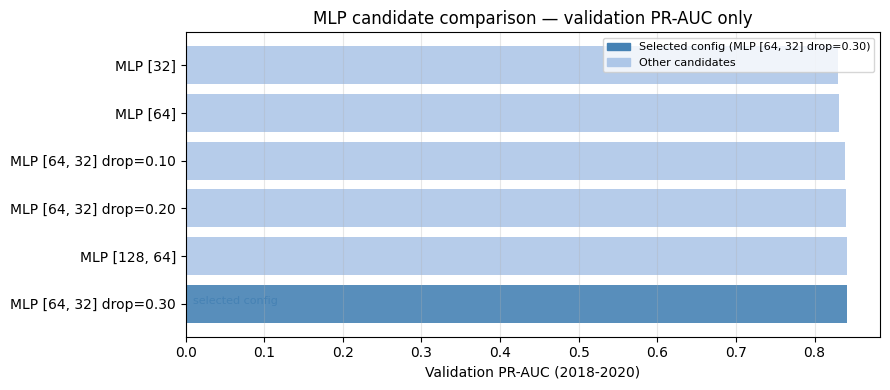


Ranked validation PR-AUC scores:
  1. MLP [64, 32] drop=0.30          0.8412 ← selected
  2. MLP [128, 64]                   0.8408
  3. MLP [64, 32] drop=0.20          0.8405
  4. MLP [64, 32] drop=0.10          0.8390
  5. MLP [64]                        0.8308
  6. MLP [32]                        0.8300


In [22]:
# =========================
# MLP configuration search — validation PR-AUC comparison
# Trains each candidate on 1984-2017, evaluates on 2018-2020 validation only.
# Test set is NOT used here.
# =========================
RUN_MLP_CONFIG_SEARCH = True

MLP_SEARCH_CANDIDATES: List[MLPTrainingConfig] = [
    # --- Depth ablation (dropout fixed at 0.20) ---
    MLPTrainingConfig(
        model_name="MLP [32]",
        hidden_layer_sizes=[32],
        dropout_rates=[0.20],
        learning_rate=1e-3,
        weight_decay=1e-3,
        batch_size=128,
        max_epochs=250,
        patience=30,
        random_state=RANDOM_STATE,
    ),
    MLPTrainingConfig(
        model_name="MLP [64]",
        hidden_layer_sizes=[64],
        dropout_rates=[0.20],
        learning_rate=1e-3,
        weight_decay=1e-3,
        batch_size=128,
        max_epochs=250,
        patience=30,
        random_state=RANDOM_STATE,
    ),
    MLPTrainingConfig(
        model_name="MLP [64, 32] drop=0.20",
        hidden_layer_sizes=[64, 32],
        dropout_rates=[0.20, 0.20],
        learning_rate=1e-3,
        weight_decay=1e-3,
        batch_size=128,
        max_epochs=250,
        patience=30,
        random_state=RANDOM_STATE,
    ),
    MLPTrainingConfig(
        model_name="MLP [128, 64]",
        hidden_layer_sizes=[128, 64],
        dropout_rates=[0.20, 0.20],
        learning_rate=1e-3,
        weight_decay=1e-3,
        batch_size=128,
        max_epochs=250,
        patience=30,
        random_state=RANDOM_STATE,
    ),
    # --- Dropout ablation (architecture fixed at [64, 32]) ---
    MLPTrainingConfig(
        model_name="MLP [64, 32] drop=0.10",
        hidden_layer_sizes=[64, 32],
        dropout_rates=[0.10, 0.10],
        learning_rate=1e-3,
        weight_decay=1e-3,
        batch_size=128,
        max_epochs=250,
        patience=30,
        random_state=RANDOM_STATE,
    ),
    MLPTrainingConfig(
        model_name="MLP [64, 32] drop=0.30",
        hidden_layer_sizes=[64, 32],
        dropout_rates=[0.30, 0.30],
        learning_rate=1e-3,
        weight_decay=1e-3,
        batch_size=128,
        max_epochs=250,
        patience=30,
        random_state=RANDOM_STATE,
    ),
]

if RUN_MLP_CONFIG_SEARCH:
    print(f"MLP configuration search — {len(MLP_SEARCH_CANDIDATES)} candidates")
    print("Validation set only (2018-2020). Test set not used.\n")

    search_rows: List[Dict[str, Any]] = []

    # Prepare scaled arrays once — shared across all candidates
    X_train_sc, X_val_sc, _, _imp, _sca = prepare_mlp_arrays(X_train, X_val, X_test)

    for cfg in MLP_SEARCH_CANDIDATES:
        set_random_seed(cfg.random_state)

        cand_model = RowLevelMLP(
            input_dim=X_train_sc.shape[1],
            hidden_layer_sizes=cfg.hidden_layer_sizes,
            dropout_rates=cfg.dropout_rates,
        ).to(torch_device)

        neg_n = int((y_train == 0).sum())
        pos_n = int((y_train == 1).sum())
        pw = torch.tensor([neg_n / max(pos_n, 1)], dtype=torch.float32, device=torch_device)
        loss_fn = nn.BCEWithLogitsLoss(pos_weight=pw)
        opt = torch.optim.AdamW(
            cand_model.parameters(), lr=cfg.learning_rate, weight_decay=cfg.weight_decay
        )

        best_val_pr   = -math.inf
        no_improve    = 0
        train_loader_c = make_data_loader(X_train_sc, y_train, cfg.batch_size, shuffle=True)

        for epoch in range(1, cfg.max_epochs + 1):
            cand_model.train()
            for fb, tb in train_loader_c:
                fb, tb = fb.to(torch_device), tb.to(torch_device)
                opt.zero_grad()
                loss_fn(cand_model(fb), tb).backward()
                opt.step()

            val_pr = safe_average_precision(
                y_val,
                predict_mlp_probabilities(cand_model, X_val_sc, cfg.batch_size)
            )

            if val_pr > best_val_pr:
                best_val_pr = val_pr
                no_improve  = 0
            else:
                no_improve += 1
                if no_improve >= cfg.patience:
                    break

        n_params = sum(p.numel() for p in cand_model.parameters() if p.requires_grad)
        search_rows.append({
            "Candidate":        cfg.model_name,
            "Architecture":     str(cfg.hidden_layer_sizes),
            "Dropout":          str(cfg.dropout_rates),
            "Val PR-AUC":       round(best_val_pr, 4),
            "Trainable params": n_params,
        })
        print(f"  {cfg.model_name:<30}  val PR-AUC = {best_val_pr:.4f}  params = {n_params}")

    # Results table — sorted by Val PR-AUC descending, no pass/fail
    mlp_search_results = (
        pd.DataFrame(search_rows)
        .sort_values("Val PR-AUC", ascending=False)
        .reset_index(drop=True)
    )
    save_result_table(mlp_search_results, "mlp_config_search_results.csv")

    print()
    display(mlp_search_results)

    # Bar chart for visual comparison
    fig, ax = plt.subplots(figsize=(9, 4))
    colors = [
        "steelblue" if "64, 32" in row["Candidate"] and "0.30" in row["Candidate"]
        else "#aec7e8"
        for _, row in mlp_search_results.iterrows()
    ]
    ax.barh(
        mlp_search_results["Candidate"],
        mlp_search_results["Val PR-AUC"],
        color=colors,
        alpha=0.9,
    )
    ax.set_xlabel("Validation PR-AUC (2018-2020)")
    ax.set_title("MLP candidate comparison — validation PR-AUC only")
    ax.grid(axis="x", alpha=0.3)
    # Mark the selected config
    ax.annotate(
        "selected config",
        xy=(0, 0), xycoords="data",
        fontsize=8, color="steelblue",
        xytext=(5, 0), textcoords="offset points",
    )
    from matplotlib.patches import Patch
    ax.legend(
        handles=[
            Patch(color="steelblue", label="Selected config (MLP [64, 32] drop=0.30)"),
            Patch(color="#aec7e8",  label="Other candidates"),
        ],
        fontsize=8,
    )
    plt.tight_layout()
    plt.show()

    print()
    print("Ranked validation PR-AUC scores:")
    for rank, (_, row) in enumerate(mlp_search_results.iterrows(), 1):
        marker = " ← selected" if "64, 32" in row["Candidate"] and "0.30" in row["Candidate"] else ""
        print(f"  {rank}. {row['Candidate']:<30}  {row['Val PR-AUC']:.4f}{marker}")

else:
    mlp_search_results = pd.DataFrame()
    print("MLP config search skipped (RUN_MLP_CONFIG_SEARCH=False).")


Saved: /content/wildfire_row_level_one_day_outputs/selected_mlp_results.csv
Saved: /content/wildfire_row_level_one_day_outputs/selected_mlp_training_history.csv
Saved: /content/wildfire_row_level_one_day_outputs/selected_mlp_thresholds.csv
Saved: /content/wildfire_row_level_one_day_outputs/row_level_model_results_with_selected_mlp.csv


,Model,Validation ROC-AUC,Validation PR-AUC,Validation F1,Best threshold,Test ROC-AUC,Test PR-AUC,Test Precision,Test Recall,Test F1,n_estimators,max_depth,min_samples_leaf,max_features,learning_rate,hidden_layer_sizes,dropout_rates,weight_decay,batch_size,best_epoch
0,Selected MLP,0.857928,0.841249,0.790493,0.36,0.826902,0.756289,0.640000,0.825806,0.721127,NaN,NaN,NaN,NaN,0.001,"[64, 32]","[0.3, 0.3]",0.001,128.0,58.0
1,XGBoost,0.852334,0.837668,0.777498,0.30,0.826802,0.757153,0.612855,0.881720,0.723104,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Tuned XGBoost,0.852334,0.837668,0.777498,0.30,0.826802,0.757153,0.612855,0.881720,0.723104,250.0,3.0,NaN,NaN,0.050,NaN,NaN,NaN,NaN,NaN
3,Tuned Random Forest,0.849948,0.833112,0.779983,0.29,0.831145,0.753104,0.634304,0.843011,0.723915,500.0,10.0,3.0,sqrt,NaN,NaN,NaN,NaN,NaN,NaN
4,Random Forest,0.838413,0.812456,0.775439,0.24,0.823246,0.741322,0.645051,0.812903,0.719315,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Logistic Regression,0.826497,0.792934,0.767123,0.40,0.788848,0.689938,0.641638,0.808602,0.715509,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Dummy baseline,0.500000,0.480839,0.649415,0.05,0.500000,0.424658,0.424658,1.000000,0.596154,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


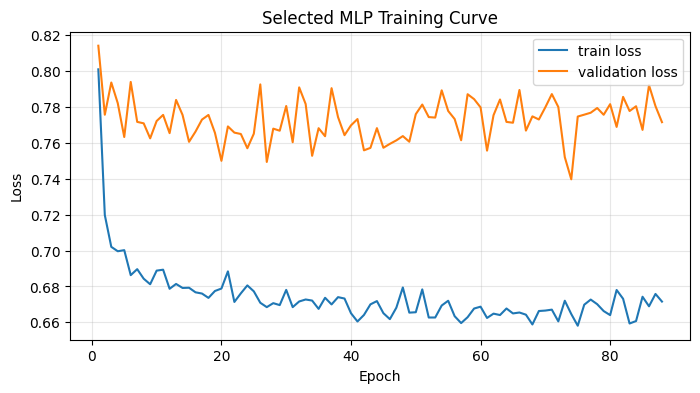

In [23]:
# =========================
# Train selected MLP
# =========================
def train_selected_mlp(
    training_config: MLPTrainingConfig,
    X_train_data: pd.DataFrame,
    y_train_data: pd.Series,
    X_validation_data: pd.DataFrame,
    y_validation_data: pd.Series,
    X_test_data: pd.DataFrame,
    y_test_data: pd.Series,
) -> Tuple[Dict[str, Any], Dict[str, Any]]:
    set_random_seed(training_config.random_state)

    X_train_scaled, X_validation_scaled, X_test_scaled, imputer, scaler = prepare_mlp_arrays(X_train_data, X_validation_data, X_test_data)
    train_loader = make_data_loader(X_train_scaled, y_train_data, training_config.batch_size, shuffle=True)

    model = RowLevelMLP(
        input_dim=X_train_scaled.shape[1],
        hidden_layer_sizes=training_config.hidden_layer_sizes,
        dropout_rates=training_config.dropout_rates,
    ).to(torch_device)

    negative_count = int((y_train_data == 0).sum())
    positive_count = int((y_train_data == 1).sum())
    positive_weight = torch.tensor([negative_count / max(positive_count, 1)], dtype=torch.float32, device=torch_device)
    loss_function = nn.BCEWithLogitsLoss(pos_weight=positive_weight)
    optimizer = torch.optim.AdamW(model.parameters(), lr=training_config.learning_rate, weight_decay=training_config.weight_decay)

    best_validation_pr_auc = -math.inf
    best_model_state: Optional[Dict[str, torch.Tensor]] = None
    best_epoch = 0
    epochs_without_improvement = 0
    training_history_rows: List[Dict[str, Any]] = []

    for epoch in range(1, training_config.max_epochs + 1):
        model.train()
        batch_losses: List[float] = []
        for feature_batch, target_batch in train_loader:
            feature_batch = feature_batch.to(torch_device)
            target_batch = target_batch.to(torch_device)

            optimizer.zero_grad()
            logits = model(feature_batch)
            loss = loss_function(logits, target_batch)
            loss.backward()
            optimizer.step()
            batch_losses.append(float(loss.detach().cpu()))

        validation_probabilities = predict_mlp_probabilities(model, X_validation_scaled, training_config.batch_size)
        validation_pr_auc = safe_average_precision(y_validation_data, validation_probabilities)
        validation_roc_auc = safe_roc_auc(y_validation_data, validation_probabilities)

        with torch.no_grad():
            validation_tensor = torch.tensor(X_validation_scaled, dtype=torch.float32, device=torch_device)
            validation_targets = torch.tensor(y_validation_data.to_numpy(dtype=np.float32), dtype=torch.float32, device=torch_device)
            validation_loss = float(loss_function(model(validation_tensor), validation_targets).detach().cpu())

        training_history_rows.append({
            "epoch": epoch,
            "train_loss": float(np.mean(batch_losses)),
            "validation_loss": validation_loss,
            "validation_pr_auc": validation_pr_auc,
            "validation_roc_auc": validation_roc_auc,
        })

        if validation_pr_auc > best_validation_pr_auc + 1e-5:
            best_validation_pr_auc = validation_pr_auc
            best_model_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= training_config.patience:
            break

    if best_model_state is None:
        best_model_state = copy.deepcopy(model.state_dict())

    final_model = restore_mlp_from_state(best_model_state, training_config, input_dim=X_train_scaled.shape[1])
    validation_probabilities = predict_mlp_probabilities(final_model, X_validation_scaled, training_config.batch_size)
    test_probabilities = predict_mlp_probabilities(final_model, X_test_scaled, training_config.batch_size)

    selected_threshold, threshold_table = tune_classification_threshold(y_validation_data, validation_probabilities)
    result_row = calculate_binary_classification_metrics(
        model_name=training_config.model_name,
        y_validation=y_validation_data,
        validation_probabilities=validation_probabilities,
        y_test_values=y_test_data,
        test_probabilities=test_probabilities,
        selected_threshold=selected_threshold,
    )
    result_row.update({
        "hidden_layer_sizes": str(training_config.hidden_layer_sizes),
        "dropout_rates": str(training_config.dropout_rates),
        "learning_rate": training_config.learning_rate,
        "weight_decay": training_config.weight_decay,
        "batch_size": training_config.batch_size,
        "best_epoch": best_epoch,
    })

    artifact = {
        "config": training_config,
        "model_state": best_model_state,
        "imputer": imputer,
        "scaler": scaler,
        "training_history": pd.DataFrame(training_history_rows),
        "threshold_table": threshold_table,
        "X_validation_scaled": X_validation_scaled,
        "X_test_scaled": X_test_scaled,
        "validation_probabilities": validation_probabilities,
        "test_probabilities": test_probabilities,
    }
    return result_row, artifact


if RUN_SELECTED_MLP:
    selected_mlp_result, selected_mlp_artifact = train_selected_mlp(
        training_config=SELECTED_MLP_CONFIG,
        X_train_data=X_train,
        y_train_data=y_train,
        X_validation_data=X_val,
        y_validation_data=y_val,
        X_test_data=X_test,
        y_test_data=y_test,
    )

    selected_mlp_results = pd.DataFrame([selected_mlp_result])
    row_level_model_results_with_mlp = pd.concat([row_level_model_results, selected_mlp_results], ignore_index=True, sort=False)
    row_level_model_results_with_mlp = row_level_model_results_with_mlp.sort_values("Validation PR-AUC", ascending=False).reset_index(drop=True)

    save_result_table(selected_mlp_results, "selected_mlp_results.csv")
    save_result_table(selected_mlp_artifact["training_history"], "selected_mlp_training_history.csv")
    save_result_table(selected_mlp_artifact["threshold_table"], "selected_mlp_thresholds.csv")
    save_result_table(row_level_model_results_with_mlp, "row_level_model_results_with_selected_mlp.csv")

    display(row_level_model_results_with_mlp)

    fig, axis = plt.subplots(figsize=(8, 4))
    training_history = selected_mlp_artifact["training_history"]
    axis.plot(training_history["epoch"], training_history["train_loss"], label="train loss")
    axis.plot(training_history["epoch"], training_history["validation_loss"], label="validation loss")
    axis.set_title("Selected MLP Training Curve")
    axis.set_xlabel("Epoch")
    axis.set_ylabel("Loss")
    axis.legend()
    axis.grid(alpha=0.3)
    plt.show()
else:
    selected_mlp_results = pd.DataFrame()
    row_level_model_results_with_mlp = row_level_model_results.copy()


## 16. Selected MLP validation permutation importance

Permutation importance is computed on validation data. It is used to interpret the selected MLP without using the test set for model selection.


Saved: /content/wildfire_row_level_one_day_outputs/selected_mlp_validation_permutation_importance.csv


,Model,Feature,Baseline validation PR-AUC,Mean PR-AUC drop,Std PR-AUC drop,Repeats
0,Selected MLP,DAY_OF_YEAR,0.841249,0.129350,0.015669,5
1,Selected MLP,MONTH,0.841249,0.085581,0.009682,5
2,Selected MLP,MAX_TEMP,0.841249,0.043918,0.006101,5
3,Selected MLP,MIN_TEMP,0.841249,0.032940,0.009213,5
4,Selected MLP,LAGGED_PRECIPITATION,0.841249,0.023673,0.008234,5
5,Selected MLP,AVG_WIND_SPEED,0.841249,0.011417,0.004417,5
6,Selected MLP,TEMP_RANGE,0.841249,0.010247,0.002683,5
7,Selected MLP,WIND_TEMP_RATIO,0.841249,0.008010,0.001997,5
8,Selected MLP,PRECIPITATION,0.841249,0.007979,0.001762,5
9,Selected MLP,LAGGED_AVG_WIND_SPEED,0.841249,0.006336,0.004668,5


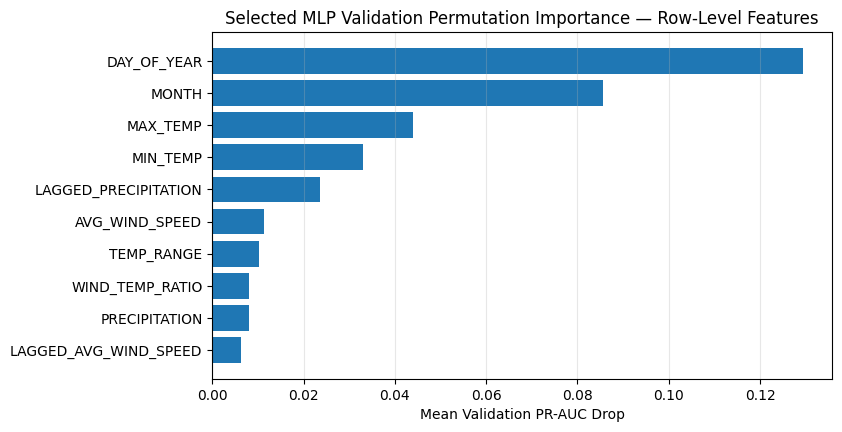

In [24]:
# =========================
# Selected MLP validation permutation importance
# =========================
def compute_selected_mlp_validation_permutation_importance(
    artifact: Dict[str, Any],
    X_validation_data: pd.DataFrame,
    y_validation_data: pd.Series,
    feature_columns: Sequence[str],
    repeats: int = PERMUTATION_REPEATS,
) -> pd.DataFrame:
    training_config: MLPTrainingConfig = artifact["config"]
    imputer: SimpleImputer = artifact["imputer"]
    scaler: StandardScaler = artifact["scaler"]
    restored_model = restore_mlp_from_state(artifact["model_state"], training_config, input_dim=len(feature_columns))

    baseline_features_imputed = imputer.transform(X_validation_data)
    baseline_features_scaled = scaler.transform(baseline_features_imputed).astype(np.float32)
    baseline_probabilities = predict_mlp_probabilities(restored_model, baseline_features_scaled, training_config.batch_size)
    baseline_pr_auc = safe_average_precision(y_validation_data, baseline_probabilities)

    importance_rows: List[Dict[str, Any]] = []
    rng = np.random.default_rng(training_config.random_state)

    for feature_index, feature_name in enumerate(feature_columns):
        pr_auc_drops = []
        for _ in range(repeats):
            permuted_features = baseline_features_scaled.copy()
            permuted_features[:, feature_index] = rng.permutation(permuted_features[:, feature_index])
            permuted_probabilities = predict_mlp_probabilities(restored_model, permuted_features, training_config.batch_size)
            permuted_pr_auc = safe_average_precision(y_validation_data, permuted_probabilities)
            pr_auc_drops.append(baseline_pr_auc - permuted_pr_auc)

        importance_rows.append({
            "Model": training_config.model_name,
            "Feature": feature_name,
            "Baseline validation PR-AUC": baseline_pr_auc,
            "Mean PR-AUC drop": float(np.mean(pr_auc_drops)),
            "Std PR-AUC drop": float(np.std(pr_auc_drops)),
            "Repeats": repeats,
        })

    return pd.DataFrame(importance_rows).sort_values("Mean PR-AUC drop", ascending=False).reset_index(drop=True)


if RUN_SELECTED_MLP and RUN_SELECTED_MLP_PERMUTATION_IMPORTANCE:
    selected_mlp_validation_importance = compute_selected_mlp_validation_permutation_importance(
        artifact=selected_mlp_artifact,
        X_validation_data=X_val,
        y_validation_data=y_val,
        feature_columns=ROW_LEVEL_FEATURE_COLUMNS,
    )
    save_result_table(selected_mlp_validation_importance, "selected_mlp_validation_permutation_importance.csv")
    display(selected_mlp_validation_importance)

    plot_table = selected_mlp_validation_importance.head(10).sort_values("Mean PR-AUC drop", ascending=True)
    fig, axis = plt.subplots(figsize=(8, 4.5))
    axis.barh(plot_table["Feature"], plot_table["Mean PR-AUC drop"])
    axis.set_title("Selected MLP Validation Permutation Importance — Row-Level Features")
    axis.set_xlabel("Mean Validation PR-AUC Drop")
    axis.grid(axis="x", alpha=0.3)
    plt.show()
else:
    selected_mlp_validation_importance = pd.DataFrame()


## 16b. MLP calibration extension

Adds the Selected MLP to the calibration diagram and summary table
produced in Section 14b. The MLP must be trained first (Section 16)
before this cell can run.

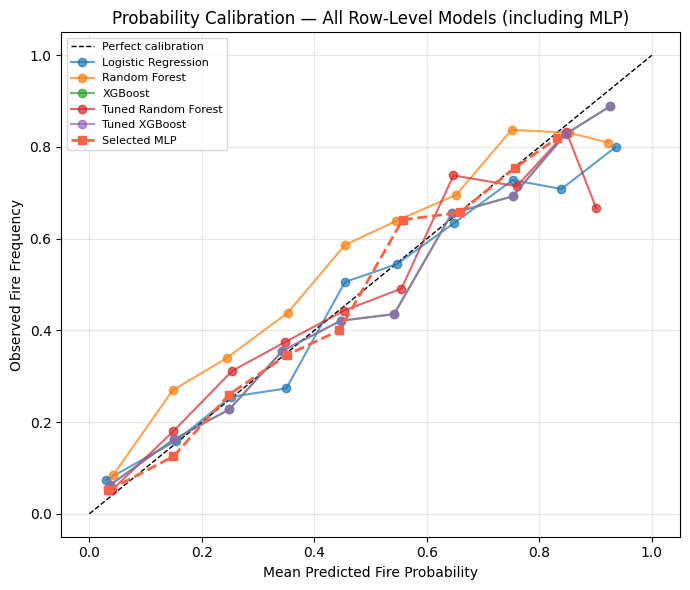

Saved: /content/wildfire_row_level_one_day_outputs/row_level_calibration_summary_with_mlp.csv


,Model,Brier score,Selected threshold,Mean predicted probability,Actual positive rate
0,Tuned Random Forest,0.1653,0.29,0.4138,0.4247
1,Selected MLP,0.1669,0.36,0.4244,0.4247
2,Tuned XGBoost,0.1674,0.30,0.4365,0.4247
3,XGBoost,0.1674,0.30,0.4365,0.4247
4,Random Forest,0.1759,0.24,0.3550,0.4247
5,Logistic Regression,0.1853,0.40,0.4418,0.4247



Selected MLP  Brier=0.1669  mean_prob=0.4244  threshold=0.36  actual_rate=0.4247

All models above the diagonal are underconfident — predicted
probabilities are lower than observed fire rates, explaining
why validation-tuned thresholds fall below 0.50 for all models.


In [25]:
# =========================
# MLP calibration extension
# Columns in threshold_table: 'threshold', 'precision', 'recall', 'f1'
# =========================
if RUN_CALIBRATION and RUN_SELECTED_MLP and selected_mlp_artifact:
    from sklearn.calibration import calibration_curve
    from sklearn.metrics import brier_score_loss

    # Restore the trained MLP
    restored_mlp = restore_mlp_from_state(
        selected_mlp_artifact["model_state"],
        selected_mlp_artifact["config"],
        input_dim=len(ROW_LEVEL_FEATURE_COLUMNS),
    )

    # Generate test probabilities using the same scaler/imputer from training
    X_test_imp = selected_mlp_artifact["imputer"].transform(X_test)
    X_test_sc  = selected_mlp_artifact["scaler"].transform(X_test_imp).astype("float32")
    mlp_test_proba = predict_mlp_probabilities(
        restored_mlp, X_test_sc, selected_mlp_artifact["config"].batch_size
    )

    # Get MLP best threshold from artifact threshold_table
    # Columns are: 'threshold', 'precision', 'recall', 'f1'
    mlp_thr_table   = selected_mlp_artifact["threshold_table"]
    mlp_best_thr    = float(
        mlp_thr_table.loc[mlp_thr_table["f1"].idxmax(), "threshold"]
    )

    mlp_brier = brier_score_loss(y_test, mlp_test_proba)
    mlp_prob_true, mlp_prob_pred = calibration_curve(
        y_test, mlp_test_proba, n_bins=10, strategy="uniform"
    )

    # Rebuild full calibration plot including MLP
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")

    # Re-plot tree models
    for model_name in CALIBRATION_MODEL_NAMES:
        if model_name not in row_level_model_lookup:
            continue
        model_proba = get_positive_class_probabilities(
            row_level_model_lookup[model_name], X_test
        )
        pt, pp = calibration_curve(
            y_test, model_proba, n_bins=10, strategy="uniform"
        )
        ax.plot(pp, pt, marker="o", linewidth=1.5, alpha=0.7, label=model_name)

    # Add MLP as distinct dashed line
    ax.plot(
        mlp_prob_pred, mlp_prob_true,
        marker="s", linewidth=2.0, linestyle="--",
        color="tomato", label="Selected MLP",
    )

    ax.set_title("Probability Calibration — All Row-Level Models (including MLP)")
    ax.set_xlabel("Mean Predicted Fire Probability")
    ax.set_ylabel("Observed Fire Frequency")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Build MLP calibration row and append to existing summary
    mlp_cal_row = pd.DataFrame([{
        "Model":                     "Selected MLP",
        "Brier score":               round(mlp_brier, 4),
        "Selected threshold":        mlp_best_thr,
        "Mean predicted probability": round(float(np.mean(mlp_test_proba)), 4),
        "Actual positive rate":      round(float(y_test.mean()), 4),
    }])

    calibration_summary_full = (
        pd.concat([calibration_summary, mlp_cal_row], ignore_index=True)
        .sort_values("Brier score")
        .reset_index(drop=True)
    )
    save_result_table(
        calibration_summary_full,
        "row_level_calibration_summary_with_mlp.csv"
    )
    display(calibration_summary_full)

    print()
    print(f"Selected MLP  Brier={mlp_brier:.4f}  "
          f"mean_prob={np.mean(mlp_test_proba):.4f}  "
          f"threshold={mlp_best_thr}  "
          f"actual_rate={y_test.mean():.4f}")
    print()
    print("All models above the diagonal are underconfident — predicted")
    print("probabilities are lower than observed fire rates, explaining")
    print("why validation-tuned thresholds fall below 0.50 for all models.")

else:
    print("MLP calibration skipped "
          "(RUN_CALIBRATION or RUN_SELECTED_MLP is False, "
          "or MLP not yet trained).")


## 17. Final model comparison with selected MLP

This section shows the final row-level model table, including the selected row-level MLP.


,Model,Validation ROC-AUC,Validation PR-AUC,Validation F1,Best threshold,Test ROC-AUC,Test PR-AUC,Test Precision,Test Recall,Test F1,n_estimators,max_depth,min_samples_leaf,max_features,learning_rate,hidden_layer_sizes,dropout_rates,weight_decay,batch_size,best_epoch
0,Selected MLP,0.857928,0.841249,0.790493,0.36,0.826902,0.756289,0.640000,0.825806,0.721127,NaN,NaN,NaN,NaN,0.001,"[64, 32]","[0.3, 0.3]",0.001,128.0,58.0
1,XGBoost,0.852334,0.837668,0.777498,0.30,0.826802,0.757153,0.612855,0.881720,0.723104,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Tuned XGBoost,0.852334,0.837668,0.777498,0.30,0.826802,0.757153,0.612855,0.881720,0.723104,250.0,3.0,NaN,NaN,0.050,NaN,NaN,NaN,NaN,NaN
3,Tuned Random Forest,0.849948,0.833112,0.779983,0.29,0.831145,0.753104,0.634304,0.843011,0.723915,500.0,10.0,3.0,sqrt,NaN,NaN,NaN,NaN,NaN,NaN
4,Random Forest,0.838413,0.812456,0.775439,0.24,0.823246,0.741322,0.645051,0.812903,0.719315,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Logistic Regression,0.826497,0.792934,0.767123,0.40,0.788848,0.689938,0.641638,0.808602,0.715509,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Dummy baseline,0.500000,0.480839,0.649415,0.05,0.500000,0.424658,0.424658,1.000000,0.596154,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


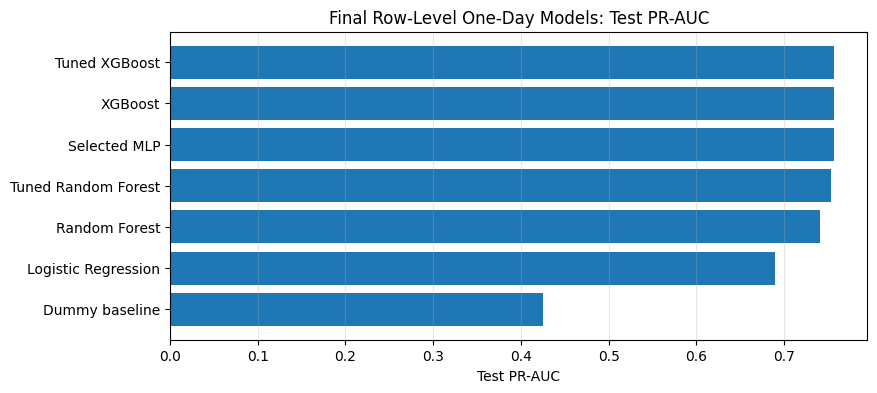

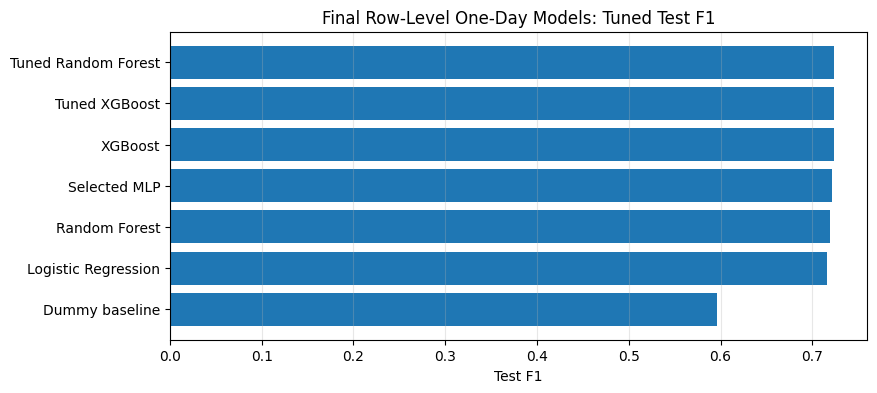

In [26]:
# =========================
# Final row-level model comparison
# =========================
if not row_level_model_results_with_mlp.empty:
    display(row_level_model_results_with_mlp)
    plot_metric_comparison(row_level_model_results_with_mlp, "Test PR-AUC", "Final Row-Level One-Day Models: Test PR-AUC")
    plot_metric_comparison(row_level_model_results_with_mlp, "Test F1", "Final Row-Level One-Day Models: Tuned Test F1")


## 18. Output manifest and final notes

The row_level analysis should be reported as the primary final methodology. The temporal-windowed branch remains useful for explaining the project progression and for feature-level comparison, but not as the final predictive setup.


In [27]:
# =========================
# Output manifest and runtime
# =========================
created_output_files = sorted(OUTPUT_DIR.glob("*.csv"))
output_manifest = pd.DataFrame({
    "file_name": [output_file.name for output_file in created_output_files],
    "path": [str(output_file) for output_file in created_output_files],
})
manifest_path = OUTPUT_DIR / "row_level_final_output_manifest.csv"
output_manifest.to_csv(manifest_path, index=False)

display(output_manifest)

elapsed_seconds = time.time() - NOTEBOOK_START_TIME
print(f"Final row-level notebook completed in {elapsed_seconds:.1f} seconds ({elapsed_seconds / 60:.1f} minutes).")
print(f"Manifest saved to: {manifest_path}")


,file_name,path
0,mlp_config_search_results.csv,/content/wildfire_row_level_one_day_outputs/ml...
1,row_level_annual_fire_summary.csv,/content/wildfire_row_level_one_day_outputs/ro...
2,row_level_calibration_summary.csv,/content/wildfire_row_level_one_day_outputs/ro...
3,row_level_calibration_summary_with_mlp.csv,/content/wildfire_row_level_one_day_outputs/ro...
4,row_level_core_model_results.csv,/content/wildfire_row_level_one_day_outputs/ro...
5,row_level_error_type_summary.csv,/content/wildfire_row_level_one_day_outputs/ro...
6,row_level_errors_by_season.csv,/content/wildfire_row_level_one_day_outputs/ro...
7,row_level_errors_by_year.csv,/content/wildfire_row_level_one_day_outputs/ro...
8,row_level_feature_importance_logistic_regressi...,/content/wildfire_row_level_one_day_outputs/ro...
9,row_level_feature_importance_random_forest.csv,/content/wildfire_row_level_one_day_outputs/ro...


Final row-level notebook completed in 316.8 seconds (5.3 minutes).
Manifest saved to: /content/wildfire_row_level_one_day_outputs/row_level_final_output_manifest.csv


### Final-report notes

- The row-level task is row-level one-day prediction.
- Rolling multi-day windows are not used as the final modeling setup because the dataset lacks a location identifier.
- LSTM/GRU models are excluded from this row_level notebook because they rely on sequence structure.
- The selected MLP is a feed-forward row-level neural baseline, not a temporal sequence model.
- Validation data is used for threshold selection and model/hyperparameter selection. The test set is used for final held-out evaluation.
- Feature relevance is interpreted primarily from row-level RF/XGBoost models, with validation permutation importance used for the selected MLP.
